In [1]:
import os
import json
import hashlib
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from umap import UMAP
import hdbscan
from sklearn.cluster import AgglomerativeClustering
from anytree import Node, RenderTree
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_json("icecat_data_train.json")
df.head(5)

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,...,ProductSeries.Language,ProductSeries.Value,BulletPoints.BulletPointsId,BulletPoints.Language,BulletPoints.Updated,BulletPoints.Values,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_...,ASUS,https://images.icecat.biz/img/brand/thumb/161_...,K31CD-IT049T,[],153,EN,PCs/Workstations,...,None,None,NaN,None,None,None,"[{'VirtualCategoryID': 195, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...
906402,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,686915-A41,[],2509,EN,Notebook Spare Parts,...,None,None,NaN,None,None,None,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...
411281,C2G,,https://images.icecat.biz/img/brand/thumb/2834...,C2G,https://images.icecat.biz/img/brand/thumb/2834...,37745,[],953,EN,Fibre Optic Cables,...,None,None,NaN,None,None,None,None,NaN,2833>830>953,Computers & Electronics>Computer Cables>Fibre ...
425903,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,FA889AA#AC3,[],8194,EN,Handheld Mobile Computer Spare Parts,...,None,None,NaN,None,None,None,None,NaN,2833>150>8194,Computers & Electronics>Computers>Handheld Mob...
1047582,Lenovo,,https://images.icecat.biz/img/brand/thumb/728_...,Lenovo,https://images.icecat.biz/img/brand/thumb/728_...,109559U,[],153,EN,PCs/Workstations,...,None,None,NaN,None,None,None,"[{'VirtualCategoryID': 194, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...


In [3]:
#checking 3-Level & 4-level C-Categories 
def split_path(path):
    if not isinstance(path, str):
        return []
    parts = [p.strip() for p in path.split(">") if p.strip()]
    return parts

df["num_levels"] = df["pathlist_names"].apply(lambda x: len(split_path(x)))

print("Counts BEFORE cleaning:")
print(df["num_levels"].value_counts().sort_index())

Counts BEFORE cleaning:
num_levels
3    289865
4    200037
Name: count, dtype: int64


In [4]:
##Keep the product,  but drop the 4th level and use only the first three levels (A > B > C).
import pandas as pd

def make_3_and_4(path):
    parts = split_path(path)

    # default
    path_3 = None
    level_4 = None

    if len(parts) >= 3:
        path_3 = " > ".join(parts[:3])   # A > B > C
    if len(parts) >= 4:
        level_4 = parts[3]               # D (4th level)

    return pd.Series({"path_3": path_3, "level_4": level_4})

df[["path_3", "level_4"]] = df["pathlist_names"].apply(make_3_and_4)

print(df[["pathlist_names", "path_3", "level_4"]].head(10))


                                            pathlist_names  \
1072689  Computers & Electronics>Computers>PCs/Workstat...   
906402   Computers & Electronics>Computers>Notebook Par...   
411281   Computers & Electronics>Computer Cables>Fibre ...   
425903   Computers & Electronics>Computers>Handheld Mob...   
1047582  Computers & Electronics>Computers>PCs/Workstat...   
904910   Computers & Electronics>Computers>Notebook Par...   
157385   Computers & Electronics>Software>Software Lice...   
934548   Computers & Electronics>Computers>Notebook Par...   
876762   Computers & Electronics>Computers>Notebook Par...   
397028   Computers & Electronics>Telecom & Navigation>M...   

                                                    path_3  \
1072689  Computers & Electronics > Computers > PCs/Work...   
906402   Computers & Electronics > Computers > Notebook...   
411281   Computers & Electronics > Computer Cables > Fi...   
425903   Computers & Electronics > Computers > Handheld...   
1047582

In [5]:
print("Rows:", len(df))
print("Unique num_levels (original):")
print(df["num_levels"].value_counts().sort_index())

print("\nCheck how many have a 4th level stored:")
print(df["level_4"].notna().sum(), "rows with level_4")


Rows: 489902
Unique num_levels (original):
num_levels
3    289865
4    200037
Name: count, dtype: int64

Check how many have a 4th level stored:
200037 rows with level_4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489902 entries, 1072689 to 1008771
Data columns (total 48 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Brand                                       489902 non-null  object 
 1   BrandInfo.BrandLocalName                    489902 non-null  object 
 2   BrandInfo.BrandLogo                         488765 non-null  object 
 3   BrandInfo.BrandName                         489902 non-null  object 
 4   BrandLogo                                   488765 non-null  object 
 5   BrandPartCode                               489902 non-null  object 
 6   BulletPoints                                455119 non-null  object 
 7   Category.CategoryID                         489902 non-null  int64  
 8   Category.Name.Language                      489902 non-null  object 
 9   Category.Name.Value                         489902 non-null  object 

In [7]:
# Extract A, B, C from path_3
df[["A", "B", "C"]] = (
    df["path_3"]
    .str.split(">", expand=True)
    .apply(lambda col: col.str.strip())
)


In [8]:
df.head()

,Brand,BrandInfo.BrandLocalName,BrandInfo.BrandLogo,BrandInfo.BrandName,BrandLogo,BrandPartCode,BulletPoints,Category.CategoryID,Category.Name.Language,Category.Name.Value,...,VirtualCategory,SummaryDescription,pathlist_ids,pathlist_names,num_levels,path_3,level_4,A,B,C
1072689,ASUS,,https://images.icecat.biz/img/brand/thumb/161_...,ASUS,https://images.icecat.biz/img/brand/thumb/161_...,K31CD-IT049T,[],153,EN,PCs/Workstations,...,"[{'VirtualCategoryID': 195, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...,3,Computers & Electronics > Computers > PCs/Work...,None,Computers & Electronics,Computers,PCs/Workstations
906402,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,686915-A41,[],2509,EN,Notebook Spare Parts,...,None,NaN,2833>150>8355>2509,Computers & Electronics>Computers>Notebook Par...,4,Computers & Electronics > Computers > Notebook...,Notebook Spare Parts,Computers & Electronics,Computers,Notebook Parts & Accessories
411281,C2G,,https://images.icecat.biz/img/brand/thumb/2834...,C2G,https://images.icecat.biz/img/brand/thumb/2834...,37745,[],953,EN,Fibre Optic Cables,...,None,NaN,2833>830>953,Computers & Electronics>Computer Cables>Fibre ...,3,Computers & Electronics > Computer Cables > Fi...,None,Computers & Electronics,Computer Cables,Fibre Optic Cables
425903,HP,,https://images.icecat.biz/img/brand/thumb/1_91...,HP,https://images.icecat.biz/img/brand/thumb/1_91...,FA889AA#AC3,[],8194,EN,Handheld Mobile Computer Spare Parts,...,None,NaN,2833>150>8194,Computers & Electronics>Computers>Handheld Mob...,3,Computers & Electronics > Computers > Handheld...,None,Computers & Electronics,Computers,Handheld Mobile Computer Spare Parts
1047582,Lenovo,,https://images.icecat.biz/img/brand/thumb/728_...,Lenovo,https://images.icecat.biz/img/brand/thumb/728_...,109559U,[],153,EN,PCs/Workstations,...,"[{'VirtualCategoryID': 194, 'UNCATID': '431718...",NaN,2833>150>153,Computers & Electronics>Computers>PCs/Workstat...,3,Computers & Electronics > Computers > PCs/Work...,None,Computers & Electronics,Computers,PCs/Workstations


In [9]:
# Basic Stats
print("Total products:", len(df))
print("Unique A-level:", df["A"].nunique())
print("Unique B-level:", df["B"].nunique())
print("Unique C-level:", df["C"].nunique())


Total products: 489902
Unique A-level: 1
Unique B-level: 17
Unique C-level: 231


In [10]:
#Distribution of A / B / C/
print("\nProducts per A-level:")
print(df["A"].value_counts())

print("\nProducts per B-level (top 10):")
print(df["B"].value_counts().head(20))

print("\nProducts per C-level (top 10):")
print(df["C"].value_counts().head(20))

print("\nProducts per C-level (bottom 10):")
print(df["C"].value_counts().tail(10))



Products per A-level:
A
Computers & Electronics    489902
Name: count, dtype: int64

Products per B-level (top 10):
B
Computers                           221663
Printers & Scanners                  36107
Software                             30639
Computer Components                  29880
Warranty & Support                   29108
Data Storage                         25346
TVs & Monitors                       24611
Computer Cables                      20598
Telecom & Navigation                 19208
Batteries & Power Supplies           12306
Data Input Devices                   10514
Consumer Audio & Video Equipment      8499
Projectors                            7795
Photo & Video Equipment               6433
Networking                            5829
Office Electronics                     817
Smart Wearables                        549
Name: count, dtype: int64

Products per C-level (top 10):
C
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & S

In [11]:
# C-level Imbalance Quantiles
# (This shows how skewed leaf categories are)
prod_per_C = df["C"].value_counts()

print("\nC-level product quantiles:")
print(prod_per_C.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))



C-level product quantiles:
0.10      25.0
0.25      53.0
0.50     173.0
0.75     716.5
0.90    3226.0
Name: count, dtype: float64


In [12]:
# Basic counts
print("Total products:", len(df))
print("Unique A levels:", df["A"].nunique())
print("Unique B levels:", df["B"].nunique())
print("Unique C levels:", df["C"].nunique())

# Compute product counts
prod_A = df["A"].value_counts()
prod_B = df["B"].value_counts()
prod_C = df["C"].value_counts()


Total products: 489902
Unique A levels: 1
Unique B levels: 17
Unique C levels: 231


In [13]:
# Identify problematic A/B/C categories
# Very large categories (top 10)
print("\n🔥 TOP 10 LARGEST C categories:")
print(prod_C.head(10))

# Very small categories (bottom 10)
print("\n❗ BOTTOM 20 SMALLEST C categories:")
print(prod_C.tail(20))

# C categories with < 30 products
weak_C = prod_C[prod_C < 30]
print("\n❗ Weak C categories (<10 products):", len(weak_C))
print(weak_C.head(20))

# B categories with < 3 C children
C_children_per_B = df.groupby("B")["C"].nunique()
weak_B = C_children_per_B[C_children_per_B < 3]

print("\n❗ Weak B categories (<3 C children):", len(weak_B))
print(weak_B.head(20))



🔥 TOP 10 LARGEST C categories:
C
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & Support Extensions    27223
Data Storage Devices             24134
Software Licenses/Upgrades       22976
PCs/Workstations                 22262
System Components                21101
Printing Supplies                20676
Chassis Components                8176
TVs                               8110
Name: count, dtype: int64

❗ BOTTOM 20 SMALLEST C categories:
C
Network Management Devices                     23
Touch Pads                                     23
KVM Extenders                                  22
Parallel Cables                                22
Cable Boots                                    22
Car Kits                                       22
Selfie Sticks                                  21
Remote Power Controllers                       21
Public Address (PA) Systems                    21
Fax Supplies                                   21
Network Cabl

In [14]:
#Identify dominant categories (too large)
# Very large C categories (skewing the distribution)
dominant_C = prod_C[prod_C > prod_C.quantile(0.95)]

print("\n🔥 Dominant C categories (>95th percentile):", len(dominant_C))
print(dominant_C)



🔥 Dominant C categories (>95th percentile): 12
C
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & Support Extensions    27223
Data Storage Devices             24134
Software Licenses/Upgrades       22976
PCs/Workstations                 22262
System Components                21101
Printing Supplies                20676
Chassis Components                8176
TVs                               8110
Keyboards                         7857
Printing Equipment                7140
Name: count, dtype: int64


In [15]:
B_summary = (
    df.groupby(["A", "B"])
      .agg(num_products=("C", "count"),
           num_C=("C", "nunique"))
      .reset_index()
      .sort_values("num_products", ascending=False)
)

print(" B-level imbalance summary:")
print(B_summary.head(20))


 B-level imbalance summary:
                          A                                 B  num_products  \
3   Computers & Electronics                         Computers        221663   
10  Computers & Electronics               Printers & Scanners         36107   
13  Computers & Electronics                          Software         30639   
2   Computers & Electronics               Computer Components         29880   
16  Computers & Electronics                Warranty & Support         29108   
6   Computers & Electronics                      Data Storage         25346   
14  Computers & Electronics                    TVs & Monitors         24611   
1   Computers & Electronics                   Computer Cables         20598   
15  Computers & Electronics              Telecom & Navigation         19208   
0   Computers & Electronics        Batteries & Power Supplies         12306   
5   Computers & Electronics                Data Input Devices         10514   
4   Computers & Electron

In [16]:
def report_AB(df):
    grouped = (
        df.groupby(["A", "B"])
          .agg(
              num_C=("C", "nunique"),
              num_products=("C", "size")
          )
          .reset_index()
    )

    for a in grouped["A"].unique():
        print(f"\nA: {a}")
        print("="*80)
        temp = grouped[grouped["A"] == a]
        for _, row in temp.iterrows():
            print(f"  B: {row['B']}")
            print(f"    #C-level subcategories: {row['num_C']}")
            print(f"    #products (total under this B): {row['num_products']}")


In [17]:
report_AB(df)


A: Computers & Electronics
  B: Batteries & Power Supplies
    #C-level subcategories: 12
    #products (total under this B): 12306
  B: Computer Cables
    #C-level subcategories: 34
    #products (total under this B): 20598
  B: Computer Components
    #C-level subcategories: 5
    #products (total under this B): 29880
  B: Computers
    #C-level subcategories: 24
    #products (total under this B): 221663
  B: Consumer Audio & Video Equipment
    #C-level subcategories: 31
    #products (total under this B): 8499
  B: Data Input Devices
    #C-level subcategories: 11
    #products (total under this B): 10514
  B: Data Storage
    #C-level subcategories: 2
    #products (total under this B): 25346
  B: Networking
    #C-level subcategories: 30
    #products (total under this B): 5829
  B: Office Electronics
    #C-level subcategories: 7
    #products (total under this B): 817
  B: Photo & Video Equipment
    #C-level subcategories: 3
    #products (total under this B): 6433
  B: Pri

In [18]:
def report_ABC(df):
    grouped = (
        df.groupby(["A", "B", "C"])
          .size()
          .reset_index(name="num_products")
    )

    for a in grouped["A"].unique():
        print(f"\nA: {a}")
        print("="*80)
        tempA = grouped[grouped["A"] == a]

        for b in tempA["B"].unique():
            print(f"  B: {b}")
            tempB = tempA[tempA["B"] == b]

            for _, row in tempB.iterrows():
                print(f"    C: {row['C']}  ({row['num_products']} products)")


In [19]:
report_ABC(df)



A: Computers & Electronics
  B: Batteries & Power Supplies
    C: Battery Chargers  (479 products)
    C: Household Batteries  (1256 products)
    C: Notebook Power Tips  (56 products)
    C: Portable Device Management Carts & Cabinets  (19 products)
    C: Power Adapters & Inverters  (4728 products)
    C: Power Banks  (702 products)
    C: Power Distribution Units (PDUs)  (1150 products)
    C: Power Supply Units  (1140 products)
    C: UPS Batteries  (402 products)
    C: UPS Battery Cabinets  (79 products)
    C: Uninterruptible Power Supplies (UPSs)  (2249 products)
    C: Uninterruptible Power Supplies (UPSs) Accessories  (46 products)
  B: Computer Cables
    C: Audio Cables  (653 products)
    C: Cable Boots  (22 products)
    C: Cable Interface/Gender Adapters  (1906 products)
    C: Cable Protectors  (52 products)
    C: Cable Splitters or Combiners  (19 products)
    C: Coaxial Cables  (299 products)
    C: Component (YPbPr) Video Cables  (104 products)
    C: Composite Vid

In [20]:
# def report_ABC_products(df):
#     for a in df["A"].unique():
#         print(f"\nA: {a}")
#         print("="*80)
#         dfA = df[df["A"] == a]

#         for b in dfA["B"].unique():
#             print(f"  B: {b}")
#             dfB = dfA[dfA["B"] == b]

#             for c in dfB["C"].unique():
#                 dfC = dfB[dfB["C"] == c]
#                 print(f"    C: {c}  ({len(dfC)} products)")
                
#                 # show top 10 product codes
#                 for code in dfC["ProductName"].fillna("").head(10):
#                     print(f"        • {code}")


In [21]:
# report_ABC_products(df)

In [22]:
# Compute metrics
products_per_AB = df.groupby(["A", "B"]).size()
C_children_per_AB = df.groupby(["A", "B"])["C"].nunique()

# Combine
ab_summary = pd.DataFrame({
    "products_in_AB": products_per_AB,
    "n_C_children": C_children_per_AB
})

# Sort by product count descending (like your example)
ab_summary = ab_summary.sort_values("products_in_AB", ascending=False).head(10)

print(ab_summary)


                                                    products_in_AB  \
A                       B                                            
Computers & Electronics Computers                           221663   
                        Printers & Scanners                  36107   
                        Software                             30639   
                        Computer Components                  29880   
                        Warranty & Support                   29108   
                        Data Storage                         25346   
                        TVs & Monitors                       24611   
                        Computer Cables                      20598   
                        Telecom & Navigation                 19208   
                        Batteries & Power Supplies           12306   

                                                    n_C_children  
A                       B                                         
Computers & Electronics C

In [23]:
prod_per_C = df["C"].value_counts()
prod_per_C


C
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & Support Extensions    27223
Data Storage Devices             24134
Software Licenses/Upgrades       22976
                                 ...  
ISDN Access Devices                 17
Numeric Keypads                     17
AV Conferencing Bridges             17
Cassette Players                    16
Smart TV Boxes                      16
Name: count, Length: 231, dtype: int64

In [24]:
import pandas as pd

# df must already contain columns: A, B, C
# (your 290k cleaned taxonomy dataframe)

def removal_summary(df, thresholds=[10,20,30,40,50,70,100,150,200]):
    results = []

    c_counts = df['C'].value_counts()

    for t in thresholds:
        # C categories kept
        valid_C = c_counts[c_counts >= t].index
        
        # rows kept
        kept_rows = df[df['C'].isin(valid_C)]
        
        # rows removed
        removed_rows = len(df) - len(kept_rows)

        # number of C categories eliminated
        removed_categories = (c_counts < t).sum()

        results.append({
            "Threshold": f"< {t}",
            "Total Rows": len(df),
            "Rows Removed": removed_rows,
            "Rows Removed (%)": round((removed_rows/len(df))*100, 2),
            "C Categories Removed": removed_categories,
            "C Categories Kept": len(valid_C)
        })
    
    return pd.DataFrame(results)

summary_table = removal_summary(df)
summary_table


,Threshold,Total Rows,Rows Removed,Rows Removed (%),C Categories Removed,C Categories Kept
0,< 10,489902,0,0.00,0,231
1,< 20,489902,140,0.03,8,223
2,< 30,489902,661,0.13,30,201
3,< 40,489902,1234,0.25,46,185
4,< 50,489902,1680,0.34,56,175
5,< 70,489902,2444,0.50,69,162
6,< 100,489902,3809,0.78,85,146
7,< 150,489902,6992,1.43,111,120
8,< 200,489902,8009,1.63,117,114


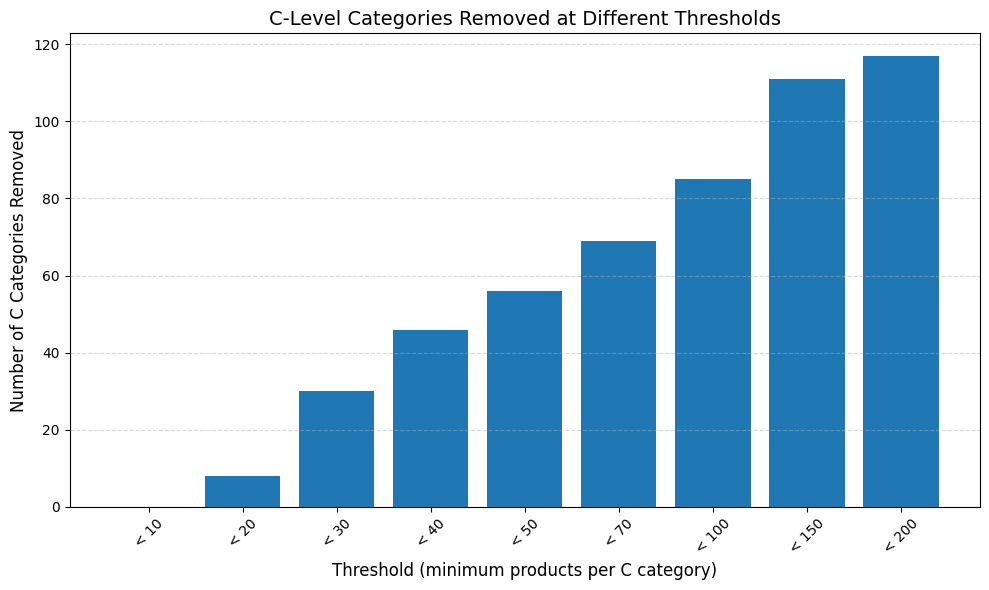

In [25]:
# Bar Chart: C Categories Removed vs Threshold
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(summary_table["Threshold"], summary_table["C Categories Removed"])

plt.title("C-Level Categories Removed at Different Thresholds", fontsize=14)
plt.xlabel("Threshold (minimum products per C category)", fontsize=12)
plt.ylabel("Number of C Categories Removed", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


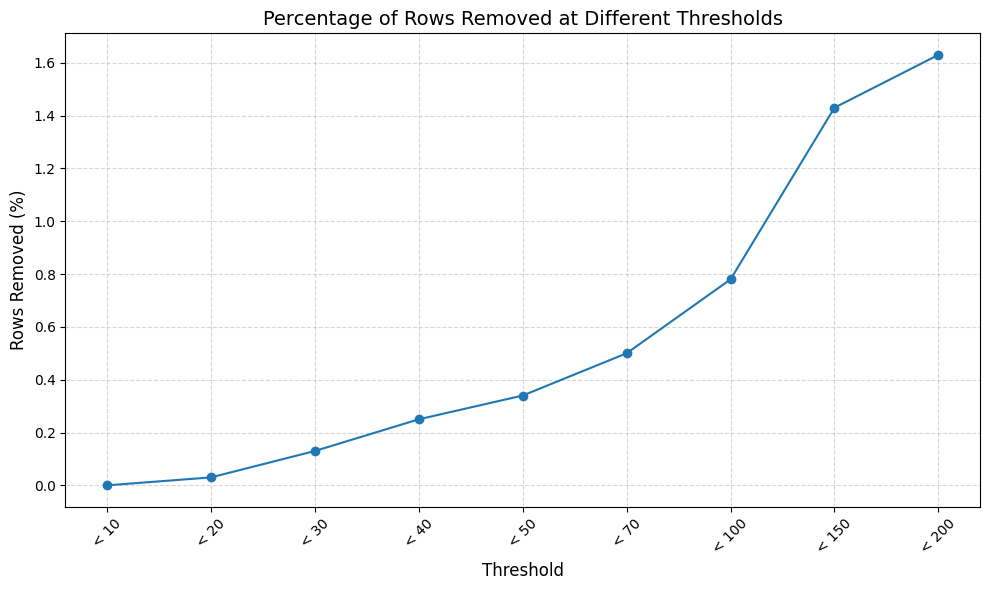

In [26]:
# Bar Chart: Rows Removed % vs Threshold
plt.figure(figsize=(10,6))

plt.plot(summary_table["Threshold"], summary_table["Rows Removed (%)"], marker='o')

plt.title("Percentage of Rows Removed at Different Thresholds", fontsize=14)
plt.xlabel("Threshold", fontsize=12)
plt.ylabel("Rows Removed (%)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


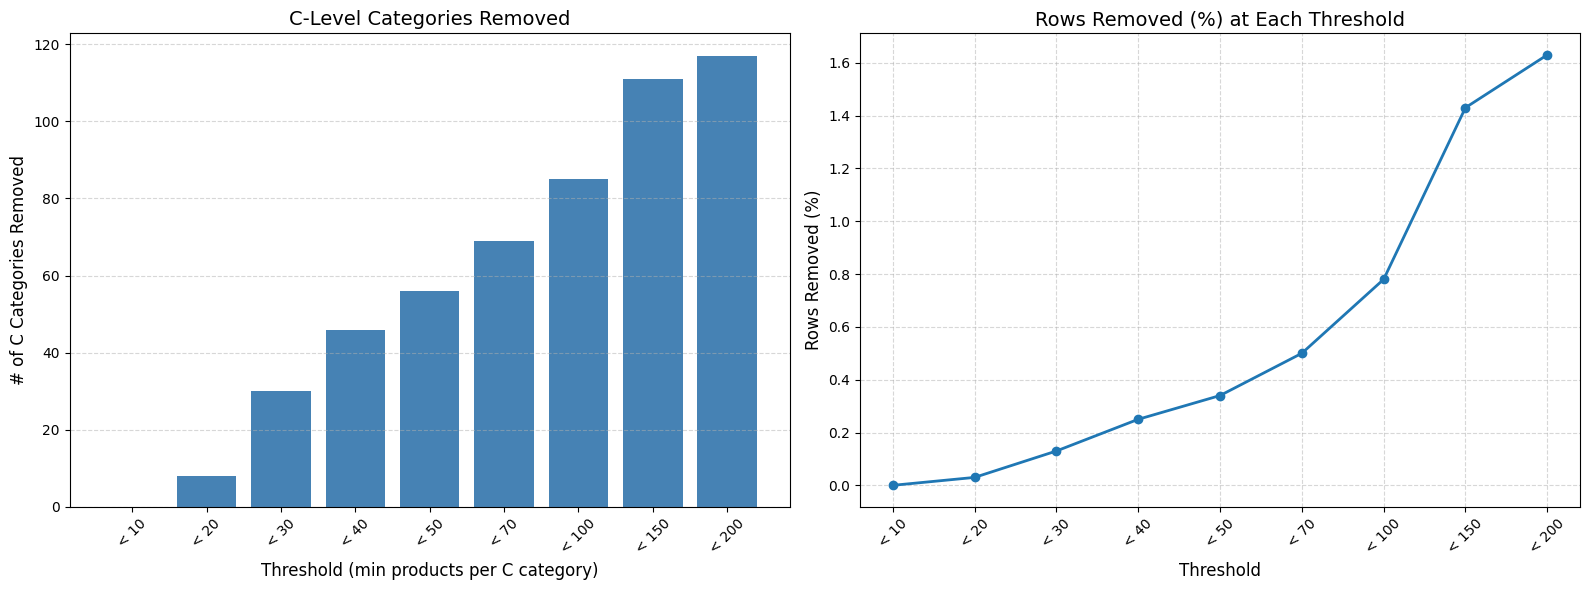

In [27]:
#Combined 2-Panel Visualization (C Categories Removed + Rows Removed%)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Panel 1: C Categories Removed ---
axes[0].bar(summary_table["Threshold"], summary_table["C Categories Removed"], color='steelblue')
axes[0].set_title("C-Level Categories Removed", fontsize=14)
axes[0].set_xlabel("Threshold (min products per C category)", fontsize=12)
axes[0].set_ylabel("# of C Categories Removed", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Rows Removed Percentage ---
axes[1].plot(summary_table["Threshold"], summary_table["Rows Removed (%)"], marker='o', linewidth=2)
axes[1].set_title("Rows Removed (%) at Each Threshold", fontsize=14)
axes[1].set_xlabel("Threshold", fontsize=12)
axes[1].set_ylabel("Rows Removed (%)", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [28]:
# Left Panel → Noise reduction
# Shows how many C-level subcategories get removed as you increase the minimum product count requirement.
# Right Panel → Data loss
# Shows how many product rows disappear from the dataset at each threshold.

In [29]:
import pandas as pd

# df must contain the C column
c_counts = df["C"].value_counts()

print("Total products:", len(df))
print("Total C-level categories:", c_counts.shape[0])

# --- 1. Basic statistics ---
average_size = c_counts.mean()
median_size = c_counts.median()

print("\nAverage C-category size:", round(average_size, 2))
print("Median C-category size:", median_size)

# --- 2. Percentiles ---
percentiles = c_counts.quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95])
print("\nPercentiles (category size):")
print(percentiles)

# --- 3. Show smallest & largest categories ---
print("\nSmallest 10 C categories:")
print(c_counts.nsmallest(10))

print("\nLargest 10 C categories:")
print(c_counts.nlargest(10))

# --- 4. Histogram bucket values (optional) ---
bins = [0, 10, 20, 50, 100, 200, 500, 1000, 5000, 100000]
hist = pd.cut(c_counts, bins=bins).value_counts().sort_index()

print("\nHistogram of C-category sizes:")
print(hist)


Total products: 489902
Total C-level categories: 231

Average C-category size: 2120.79
Median C-category size: 173.0

Percentiles (category size):
0.10      25.0
0.25      53.0
0.50     173.0
0.75     716.5
0.90    3226.0
0.95    7048.0
Name: count, dtype: float64

Smallest 10 C categories:
C
Cassette Players                               16
Smart TV Boxes                                 16
ISDN Access Devices                            17
Numeric Keypads                                17
AV Conferencing Bridges                        17
Cable Splitters or Combiners                   19
All-in-One PC/Workstation Mounts & Stands      19
Portable Device Management Carts & Cabinets    19
Paper Shredders                                20
Selfie Sticks                                  21
Name: count, dtype: int64

Largest 10 C categories:
C
Notebook Parts & Accessories     97843
Notebooks                        83488
Warranty & Support Extensions    27223
Data Storage Devices             24

In [30]:
# Average C-category size = ~2121 products
# → On average, each C-level category contains about 2,120 products.

# Median C-category size = 173 products
# → Half of the C categories have 173 or fewer products.
# → The distribution is highly skewed because a few huge categories (like “Notebooks”, “Notebook Parts & Accessories”) pull the average upward.

# The real center of your taxonomy is ~173 products per C-category.
# Categories with <50 products are clearly far below normal and should be removed.

In [31]:
# Size Range (products per C-category)	Number of C-categories
# (0, 10 products]	0 categories
# (10, 20 products]	9 categories
# (20, 50]	47 categories
# (50, 100]	30 categories
# (100, 200]	33 categories
# (200, 500]	42 categories
# (500, 1000]	20 categories
# (1000, 5000]	32 categories
# (5000, 100000]	18 categories

In [32]:
# P10 = 25 products
# 10% of C-categories have 25 or fewer products → these are very small (noisy).
# P25 = 53 products
# 25% have 53 or fewer → this matches your threshold discussion (min_C ≈ 50).
# P50 (median) = 173 products
# Half of all categories contain 173 or fewer products → the typical category is small, not huge.
# P75 = 716 products
# 75% of categories have 716 or fewer → only 25% are very large groups.
# P90 = 3,226 products
# Only 10% of categories have over 3,226 products.
# P95 = 7,048 products
# Only 5% of categories have more than 7,048 products → these huge categories pull the average up.

In [33]:
import pandas as pd

def removal_summary_with_B(df, thresholds=[10,20,30,40,50,70,100,150,173,200,500,800,1000]):
    results = []
    
    # Count C and B category sizes
    c_counts = df['C'].value_counts()
    b_counts = df['B'].value_counts()

    for t in thresholds:
        # Keep only C categories with >= t items
        valid_C = c_counts[c_counts >= t].index

        # Keep rows matching valid C
        kept_rows_df = df[df['C'].isin(valid_C)]
        
        # Rows removed
        removed_rows = len(df) - len(kept_rows_df)

        # C categories removed
        removed_C = (c_counts < t).sum()
        kept_C = len(valid_C)

        # Now compute B categories kept after removing weak C categories
        kept_B = kept_rows_df['B'].nunique()
        removed_B = df['B'].nunique() - kept_B

        results.append({
            "Threshold": f"< {t}",
            "Total Rows": len(df),
            "Rows Removed": removed_rows,
            "Rows Removed (%)": round((removed_rows/len(df))*100, 2),
            "C Categories Removed": removed_C,
            "C Categories Kept": kept_C,
            "B Categories Removed": removed_B,
            "B Categories Kept": kept_B,
        })
    
    return pd.DataFrame(results)

summary_table_BC = removal_summary_with_B(df)
summary_table_BC


,Threshold,Total Rows,Rows Removed,Rows Removed (%),C Categories Removed,C Categories Kept,B Categories Removed,B Categories Kept
0,< 10,489902,0,0.00,0,231,0,17
1,< 20,489902,140,0.03,8,223,0,17
2,< 30,489902,661,0.13,30,201,0,17
3,< 40,489902,1234,0.25,46,185,0,17
4,< 50,489902,1680,0.34,56,175,0,17
5,< 70,489902,2444,0.50,69,162,0,17
6,< 100,489902,3809,0.78,85,146,0,17
7,< 150,489902,6992,1.43,111,120,0,17
8,< 173,489902,7637,1.56,115,116,0,17
9,< 200,489902,8009,1.63,117,114,0,17


In [34]:
# Rows removed: 1680 out of 489,902
# Rows removed %: 0.34% (almost nothing)
# This means you are not losing meaningful data, only long-tail noise.

# It removes exactly the weak/unstable C-categories
# At <50:
# 56 C-categories removed
# 175 C-categories kept
# The removed categories are the ones with <50 samples, which are extremely weak for:
# keyword extraction
# embeddings
# HDBSCAN clustering
# LLM naming
# These tiny categories cause instability and bad purity.



In [35]:
#Which C categories are removed at thresholds 50, 60, 70, 80, 100
import pandas as pd

def removed_C_categories(df, thresholds=[50, 60, 70, 80, 100]):
    """
    For each threshold T, list all C categories with <T products,
    along with their product counts.
    """
    
    c_counts = df['C'].value_counts()
    results = {}

    for t in thresholds:
        removed = c_counts[c_counts < t].sort_values()
        results[f"< {t}"] = removed
    
    return results


# --- RUN IT ---
thresholds = [50, 60, 70, 80, 100]
removed_dict = removed_C_categories(df, thresholds)

# --- PRINT CLEAN OUTPUT ---
for th, categories in removed_dict.items():
    print("="*80)
    print(f"C categories REMOVED at threshold {th}:")
    print(f"(Count = {len(categories)})")
    print("-"*80)
    print(categories)
    print("\n")


C categories REMOVED at threshold < 50:
(Count = 56)
--------------------------------------------------------------------------------
C
Cassette Players                                        16
Smart TV Boxes                                          16
ISDN Access Devices                                     17
AV Conferencing Bridges                                 17
Numeric Keypads                                         17
Cable Splitters or Combiners                            19
All-in-One PC/Workstation Mounts & Stands               19
Portable Device Management Carts & Cabinets             19
Paper Shredders                                         20
Public Address (PA) Systems                             21
Fax Supplies                                            21
Network Cable Testers                                   21
Selfie Sticks                                           21
Remote Power Controllers                                21
Parallel Cables                       

In [36]:
# Which C categories are removed at <50
# ✅ How those C categories are distributed across their B parents
import pandas as pd

def removed_C_with_B(df, threshold=50):
    """
    Returns:
    1) A dataframe of removed C categories (<threshold) with product counts.
    2) A dataframe showing how these removed C categories distribute across B-level groups.
    """
    # Count category sizes
    c_counts = df["C"].value_counts()

    # Identify removed C categories (< threshold)
    removed_C = c_counts[c_counts < threshold]
    
    # Subset original df to only these removed categories
    removed_df = df[df["C"].isin(removed_C.index)][["A", "B", "C"]]

    # Count how many C categories removed per B category
    B_distribution = (
        removed_df.groupby("B")["C"]
        .nunique()               # number of C categories removed in each B
        .reset_index()
        .rename(columns={"C": "Removed_C_Count"})
        .sort_values("Removed_C_Count", ascending=False)
    )

    return removed_C, B_distribution


# ---- RUN IT ----
removed_C_50, B_dist_50 = removed_C_with_B(df, threshold=50)

print("============================================")
print("C CATEGORIES REMOVED AT THRESHOLD <50")
print("============================================")
print(f"TOTAL REMOVED: {len(removed_C_50)}\n")
print(removed_C_50.sort_values())

print("\n\n============================================")
print("B-LEVEL DISTRIBUTION OF REMOVED C CATEGORIES (<50)")
print("============================================")
print(B_dist_50)


C CATEGORIES REMOVED AT THRESHOLD <50
TOTAL REMOVED: 56

C
Cassette Players                                        16
Smart TV Boxes                                          16
ISDN Access Devices                                     17
AV Conferencing Bridges                                 17
Numeric Keypads                                         17
Cable Splitters or Combiners                            19
All-in-One PC/Workstation Mounts & Stands               19
Portable Device Management Carts & Cabinets             19
Paper Shredders                                         20
Public Address (PA) Systems                             21
Fax Supplies                                            21
Network Cable Testers                                   21
Selfie Sticks                                           21
Remote Power Controllers                                21
Parallel Cables                                         22
KVM Extenders                                           

In [37]:
#analysis shows that 56 C-level categories have fewer than 50 products.
# These are the long-tail, rare, and unstable categories in the Icecat dataset.

# Networking is a B-level category, and it contains 12 C-level subcategories that each have fewer than 50 products.

In [38]:
import pandas as pd

# Step 1.1: Count products per C category
c_counts = df["C"].value_counts()

# Step 1.2: Keep only C categories with >= 30 products
valid_C = c_counts[c_counts >= 30].index

df_min30 = df[df["C"].isin(valid_C)].copy()

print("Original rows:", len(df))
print("Rows after min 30 filter:", len(df_min30))
print("Original C categories:", df["C"].nunique())
print("C categories kept (>=30):", df_min30["C"].nunique())


Original rows: 489902
Rows after min 30 filter: 489241
Original C categories: 231
C categories kept (>=30): 201


In [39]:
# For every C category, keep at most 100 products
df_min30_max100 = (
    df_min30
    .groupby("C", group_keys=False)
    .head(100)     # keeps first 100 rows per C
    .reset_index(drop=True)
)

print("Rows after max 100 per C:", len(df_min30_max100))
print("C categories after max 100:", df_min30_max100["C"].nunique())


Rows after max 100 per C: 17748
C categories after max 100: 201


In [40]:
# 🌳 Tree View of B → C Categories With Product Counts
# Count remaining products per C
c_counts_final = df_min30_max100["C"].value_counts()

# Merge counts back to dataframe
df_tree = (
    df_min30_max100[["A", "B", "C"]]
    .drop_duplicates()
    .copy()
)

df_tree["count"] = df_tree["C"].map(c_counts_final)

# Sort for readability
df_tree = df_tree.sort_values(["B", "C"])


In [41]:
# Step 1: Count C-level products after min30/max100 filtering
c_counts_final = df_min30_max100["C"].value_counts()

# Step 2: Build unique A-B-C combinations
df_tree = (
    df_min30_max100[["A", "B", "C"]]
    .drop_duplicates()
    .copy()
)

df_tree["count"] = df_tree["C"].map(c_counts_final)

# Step 3: Sort for clean printing
df_tree = df_tree.sort_values(["A", "B", "C"])


In [42]:
current_a = None
current_b = None

for _, row in df_tree.iterrows():
    a = row["A"]
    b = row["B"]
    c = row["C"]
    cnt = row["count"]
    
    # Print A-level
    if a != current_a:
        print(f"\n🟦 A: {a}")
        current_a = a
        current_b = None
    
    # Print B-level
    if b != current_b:
        print(f"  🔷 B: {b}")
        current_b = b
    
    # Print C-level
    print(f"        └── C: {c}   ({cnt} products)")



🟦 A: Computers & Electronics
  🔷 B: Batteries & Power Supplies
        └── C: Battery Chargers   (100 products)
        └── C: Household Batteries   (100 products)
        └── C: Notebook Power Tips   (56 products)
        └── C: Power Adapters & Inverters   (100 products)
        └── C: Power Banks   (100 products)
        └── C: Power Distribution Units (PDUs)   (100 products)
        └── C: Power Supply Units   (100 products)
        └── C: UPS Batteries   (100 products)
        └── C: UPS Battery Cabinets   (79 products)
        └── C: Uninterruptible Power Supplies (UPSs)   (100 products)
        └── C: Uninterruptible Power Supplies (UPSs) Accessories   (46 products)
  🔷 B: Computer Cables
        └── C: Audio Cables   (100 products)
        └── C: Cable Interface/Gender Adapters   (100 products)
        └── C: Cable Protectors   (52 products)
        └── C: Coaxial Cables   (100 products)
        └── C: Component (YPbPr) Video Cables   (100 products)
        └── C: Composite Vi

In [43]:
df_min30_max100.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17748 entries, 0 to 17747
Data columns (total 51 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Brand                                       17748 non-null  object 
 1   BrandInfo.BrandLocalName                    17748 non-null  object 
 2   BrandInfo.BrandLogo                         17677 non-null  object 
 3   BrandInfo.BrandName                         17748 non-null  object 
 4   BrandLogo                                   17677 non-null  object 
 5   BrandPartCode                               17748 non-null  object 
 6   BulletPoints                                16282 non-null  object 
 7   Category.CategoryID                         17748 non-null  int64  
 8   Category.Name.Language                      17748 non-null  object 
 9   Category.Name.Value                         17748 non-null  object 
 10  Descriptio

In [44]:
df_min30_max100[['ProductName',"BrandPartCode","Brand","Description.LongDesc","Description.LongProductName"]]

,ProductName,BrandPartCode,Brand,Description.LongDesc,Description.LongProductName
0,K31CD-IT049T,K31CD-IT049T,ASUS,<b>Smart Multimedia Performance</b><br>\nVivoP...,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA..."
1,686915-A41,686915-A41,HP,,Keyboard in midnight black finish with backlig...
2,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,37745,C2G,Get the performance you demand at a price that...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...
3,FA889AA,FA889AA#AC3,HP,Keeping an extra source of power nearby means ...,"1100 mAh, Lithium Ion, Standard Battery"
4,C30,109559U,Lenovo,The C30 builds on its award-winning design as ...,"Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ..."
...,...,...,...,...,...
17743,ZCNE-SWITCH3,ZCNE-SWITCH3,Zyxel,<b>Empower your Expertise for the Internet Wor...,Switch ZCNE (ZyXEL Certified Network Engineer)...
17744,TOUCH-65-10P-IR,TOUCH-65-10P-IR,Toshiba,"<b>65"" Touch Kit</b><br>\nEmpower your custome...","165.1 cm (65"") , 10-point infrared touch, 15ms..."
17745,RoboSHOT 12E HDBT OneLINK HDMI,999-99600-101,Vaddio,Introducing the RoboSHOT Elite Series – Vaddio...,"8.57MP, 1/2.5 Exmor R CMOS, 12x, 1080p/60, HDM..."
17746,10.32.1002-OEM,10.32.1002-OEM,Nanocable,Phone coil of 4 wires,"Telephone cable 4C, Beige 100 m"


In [45]:
import pandas as pd

# Use the filtered df (min≥30, max≤100 per C)
df = df_min30_max100

cols_needed = [
    "Brand",
    "ProductName",
    "Description.LongProductName",
    "SummaryDescription.LongSummaryDescription",
    "Description.LongDesc",
    "A", "B", "C",
    "path_3"   # for later evaluation
]

df_clean = df[cols_needed].copy()
print(len(df_clean), "rows in df_clean")
df_clean.head(3)


17748 rows in df_clean


,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3
0,ASUS,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...
1,HP,686915-A41,Keyboard in midnight black finish with backlig...,HP 686915-A41. Type: Keyboard. Keyboard langua...,,Computers & Electronics,Computers,Notebook Parts & Accessories,Computers & Electronics > Computers > Notebook...
2,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,Get the performance you demand at a price that...,Computers & Electronics,Computer Cables,Fibre Optic Cables,Computers & Electronics > Computer Cables > Fi...


In [46]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17748 entries, 0 to 17747
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Brand                                      17748 non-null  object
 1   ProductName                                17748 non-null  object
 2   Description.LongProductName                15701 non-null  object
 3   SummaryDescription.LongSummaryDescription  17748 non-null  object
 4   Description.LongDesc                       15701 non-null  object
 5   A                                          17748 non-null  object
 6   B                                          17748 non-null  object
 7   C                                          17748 non-null  object
 8   path_3                                     17748 non-null  object
dtypes: object(9)
memory usage: 1.2+ MB


In [47]:
def build_metadata(row):
    parts = []

    if pd.notna(row["Brand"]):
        parts.append(row["Brand"])
        
    if pd.notna(row["ProductName"]):
        parts.append(row["ProductName"])

    if pd.notna(row["Description.LongProductName"]):
        parts.append(row["Description.LongProductName"])

    if pd.notna(row["SummaryDescription.LongSummaryDescription"]):
        parts.append(row["SummaryDescription.LongSummaryDescription"])

    if pd.notna(row["Description.LongDesc"]):
        parts.append(row["Description.LongDesc"])

    return " ".join(parts)

df_clean["metadata_text"] = df_clean.apply(build_metadata, axis=1)
df_clean["metadata_text"].head(3)


0    ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...
1    HP 686915-A41 Keyboard in midnight black finis...
2    C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...
Name: metadata_text, dtype: object

In [48]:
import re

def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = re.sub(r"<[^>]+>", " ", t)   # remove HTML tags
    t = re.sub(r"\s+", " ", t)       # collapse spaces
    t = t.replace("\xa0", " ")       # non-breaking space
    return t.strip()

df_clean["metadata_text_clean"] = df_clean["metadata_text"].apply(clean_text)

# length stats
df_clean["meta_len"] = df_clean["metadata_text_clean"].apply(lambda x: len(str(x)))
print(df_clean["meta_len"].describe())


count    17748.000000
mean      1107.083671
std       1260.042263
min         13.000000
25%        344.000000
50%        751.000000
75%       1381.000000
max      27349.000000
Name: meta_len, dtype: float64


In [49]:
df_clean

,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3,metadata_text,metadata_text_clean,meta_len
0,ASUS,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,3644
1,HP,686915-A41,Keyboard in midnight black finish with backlig...,HP 686915-A41. Type: Keyboard. Keyboard langua...,,Computers & Electronics,Computers,Notebook Parts & Accessories,Computers & Electronics > Computers > Notebook...,HP 686915-A41 Keyboard in midnight black finis...,HP 686915-A41 Keyboard in midnight black finis...,288
2,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,Get the performance you demand at a price that...,Computers & Electronics,Computer Cables,Fibre Optic Cables,Computers & Electronics > Computer Cables > Fi...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,1834
3,HP,FA889AA,"1100 mAh, Lithium Ion, Standard Battery","HP FA889AA. Product type: Battery, Product col...",Keeping an extra source of power nearby means ...,Computers & Electronics,Computers,Handheld Mobile Computer Spare Parts,Computers & Electronics > Computers > Handheld...,"HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...","HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...",360
4,Lenovo,C30,"Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ...",Lenovo ThinkStation C30. Processor frequency: ...,The C30 builds on its award-winning design as ...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,"Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...","Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...",2897
...,...,...,...,...,...,...,...,...,...,...,...,...
17743,Zyxel,ZCNE-SWITCH3,Switch ZCNE (ZyXEL Certified Network Engineer)...,Zyxel ZCNE-SWITCH3,<b>Empower your Expertise for the Internet Wor...,Computers & Electronics,Warranty & Support,IT Courses,Computers & Electronics > Warranty & Support >...,Zyxel ZCNE-SWITCH3 Switch ZCNE (ZyXEL Certifie...,Zyxel ZCNE-SWITCH3 Switch ZCNE (ZyXEL Certifie...,2395
17744,Toshiba,TOUCH-65-10P-IR,"165.1 cm (65"") , 10-point infrared touch, 15ms...",Toshiba TOUCH-65-10P-IR. Power source type: DC,"<b>65"" Touch Kit</b><br>\nEmpower your custome...",Computers & Electronics,TVs & Monitors,Touch Screen Overlays,Computers & Electronics > TVs & Monitors > Tou...,"Toshiba TOUCH-65-10P-IR 165.1 cm (65"") , 10-po...","Toshiba TOUCH-65-10P-IR 165.1 cm (65"") , 10-po...",1002
17745,Vaddio,RoboSHOT 12E HDBT OneLINK HDMI,"8.57MP, 1/2.5 Exmor R CMOS, 12x, 1080p/60, HDM...",Vaddio RoboSHOT 12E HDBT OneLINK HDMI. Megapix...,Introducing the RoboSHOT Elite Series – Vaddio...,Computers & Electronics,Networking,Video Conferencing Systems,Computers & Electronics > Networking > Video C...,"Vaddio RoboSHOT 12E HDBT OneLINK HDMI 8.57MP, ...","Vaddio RoboSHOT 12E HDBT OneLINK HDMI 8.57MP, ...",2373
17746,Nanocable,10.32.1002-OEM,"Telephone cable 4C, Beige 100 m","Nanocable 10.32.1002-OEM. Cable length: 100 m,...",Phone coil of 4 wires,Computers & Electronics,Networking,Telephony Cables,Computers & Electronics > Networking > Telepho...,"Nanocable 10.32.1002-OEM Telephone cable 4C, B...","Nanocable 10.32.1002-OEM Telephone cable 4C, B...",227


In [50]:
df_clean['meta_len'].max()

27349

In [51]:
import torch
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

st_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

embeddings = st_model.encode(
    df_clean["metadata_text_clean"].fillna("").tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embeddings shape:", embeddings.shape)


Using device: cuda


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/139 [00:00<?, ?it/s]

Embeddings shape: (17748, 384)


In [52]:
from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,        # local structure
    min_dist=0.0,          # tight clusters
    n_components=15,       # enough for clustering
    metric="cosine",       # best for normalized embeddings
    random_state=42
)

reduced = umap_model.fit_transform(embeddings)
print("Reduced shape:", reduced.shape)   # (17748, 10) approx


Reduced shape: (17748, 15)


In [78]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=55,          # minimum samples to form a cluster
    min_samples=1,                # allow fine-grained separation
    metric='euclidean',           # required after UMAP
    cluster_selection_method='eom'
)

labels = clusterer.fit_predict(reduced)

df_clean["cluster_id"] = labels

print("Unique clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", sum(labels == -1))
print("Noise %:", round(sum(labels == -1) / len(labels) * 100, 2))


Unique clusters: 120
Noise points: 3151
Noise %: 17.75


In [79]:
# with 25 cluster size ->
# Unique clusters: 275
# Noise points: 2908
# Noise %: 16.38

# with 20 cluster size ->
# Unique clusters: 346
# Noise points: 2646
# Noise %: 14.91

#with 35 cluster size ->
# Unique clusters: 196
# Noise points: 3263
# Noise %: 18.39

#with cluster size =40
# Unique clusters: 172
# Noise points: 3283
# Noise %: 18.5

In [80]:
import numpy as np

labels = df_clean["cluster_id"].values

Unique_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("Total clusters formed:", Unique_clusters)


Total clusters formed: 120


In [81]:
#Count clusters properly (excluding noise)
cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
cluster_sizes.head(10)


20     528
25     382
67     306
36     286
52     269
101    247
85     241
62     238
105    228
7      228
Name: count, dtype: int64

In [82]:
#Full summary statistics of cluster sizes
cluster_sizes.describe()


count    120.000000
mean     121.641667
std       69.199237
min       57.000000
25%       79.000000
50%      100.500000
75%      140.000000
max      528.000000
Name: count, dtype: float64

In [83]:
df_clean[df_clean["cluster_id"] == 45][[
    "ProductName",
    "Brand",
    "C",
    "B",
    "metadata_text_clean"
]].head(20)


,ProductName,Brand,C,B,metadata_text_clean
399,SFP13010GE0DJ34,Skylane Optics,Network Transceiver Modules,Networking,"Skylane Optics SFP13010GE0DJ34 SFP, 10000 m, M..."
465,LPE15000B-M8-D,DELL,System Components,Computer Components,DELL LPE15000B-M8-D LPe1500B-M8D Host bus Adap...
662,39617,C2G,Network Transceiver Modules,Networking,C2G 39617 Cisco QSFP-40G-SR4-S Compatible TAA ...
799,406-10402,DELL,System Components,Computer Components,DELL 406-10402 QLogic QME2572 8Gbps Fibre Chan...
1349,39660,C2G,Network Transceiver Modules,Networking,C2G 39660 Finisar FTLF8528P3BCV Compatible TAA...
1618,39638,C2G,Network Transceiver Modules,Networking,C2G 39638 MSA and TAA Compliant 1000Base-TX SF...
1927,Cisco[R] GLC-FE-100LX-RGD Compatible TAA Compl...,C2G,Network Transceiver Modules,Networking,C2G Cisco[R] GLC-FE-100LX-RGD Compatible TAA C...
2091,39723,C2G,Network Transceiver Modules,Networking,C2G 39723 Dell 407-BBOR Compatible TAA complia...
2115,39631,C2G,Network Transceiver Modules,Networking,C2G 39631 Linksys MGBLX1 Compatible TAA Compli...
2204,"155Mbps Single-mode SFP Transceiver, 40km, 1310nm",LevelOne,Network Transceiver Modules,Networking,"LevelOne 155Mbps Single-mode SFP Transceiver, ..."


In [84]:
#list all cluster and their sizes
df_clean["cluster_id"].value_counts()


cluster_id
-1      3151
 20      528
 25      382
 67      306
 36      286
        ... 
 96       61
 117      61
 44       61
 2        58
 100      57
Name: count, Length: 121, dtype: int64

In [85]:
cluster_id = 45   # ← choose any cluster

cluster_products = df_clean[df_clean["cluster_id"] == cluster_id][[
    "ProductName", "Brand", "C", "B", "metadata_text_clean"
]]

cluster_products


,ProductName,Brand,C,B,metadata_text_clean
399,SFP13010GE0DJ34,Skylane Optics,Network Transceiver Modules,Networking,"Skylane Optics SFP13010GE0DJ34 SFP, 10000 m, M..."
465,LPE15000B-M8-D,DELL,System Components,Computer Components,DELL LPE15000B-M8-D LPe1500B-M8D Host bus Adap...
662,39617,C2G,Network Transceiver Modules,Networking,C2G 39617 Cisco QSFP-40G-SR4-S Compatible TAA ...
799,406-10402,DELL,System Components,Computer Components,DELL 406-10402 QLogic QME2572 8Gbps Fibre Chan...
1349,39660,C2G,Network Transceiver Modules,Networking,C2G 39660 Finisar FTLF8528P3BCV Compatible TAA...
...,...,...,...,...,...
13081,409-BBCY,DELL,Network Switch Modules,Networking,DELL 409-BBCY SFP+ 10GbE Module 4 port Hot Swa...
14213,4 GE + 4 GE SFP Module for GSW-2453/MSL-3S79,LevelOne,Network Switch Modules,Networking,LevelOne 4 GE + 4 GE SFP Module for GSW-2453/M...
16074,470-ABBK,DELL,InfiniBand Cables,Computer Cables,"DELL 470-ABBK 5m, 10GbE SFP+ Direct Attach Cab..."
16228,4m IEEE-488 C24MF to C24MF HPIB/GPIB Bus Cable,C2G,PS/2 Cables,Computer Cables,C2G 4m IEEE-488 C24MF to C24MF HPIB/GPIB Bus C...


In [86]:
cluster_id = 24   # ← choose any cluster

cluster_products = df_clean[df_clean["cluster_id"] == cluster_id][[
    "ProductName", "Brand", "C", "B", "metadata_text_clean"
]]

cluster_products

,ProductName,Brand,C,B,metadata_text_clean
262,LM6291001,Brother,Printing Supplies,Printers & Scanners,Brother LM6291001 Brother LM6291001. Compatibi...
720,LJ0893001,Brother,Print & Scan Accessories,Printers & Scanners,Brother LJ0893001 Transfer Roller for HL-2460 ...
983,007R97230,Xerox,Printing Supplies,Printers & Scanners,Xerox 007R97230 Xerox 007R97230. Type: Origina...
1169,LC-223VALBP,Brother,Printing Supplies,Printers & Scanners,Brother LC-223VALBP LC-223VALBPValueBlister(1 ...
1313,RJ-2030,Brother,Printing Equipment,Printers & Scanners,"Brother RJ-2030 152 mm/s, IP54, LCD display, U..."
...,...,...,...,...,...
16901,PA-FFC-600H,Brother,Peripheral Device Cases,Telecom & Navigation,Brother PA-FFC-600H Fanfold Case for PocketJet...
16936,FAX-236S,Brother,Fax Machines,Office Electronics,"Brother FAX-236S FAX-236S - 9600 bit/s, 110W, ..."
17404,PAWC4000,Brother,Peripheral Device Cases,Telecom & Navigation,Brother PAWC4000 Brother PAWC4000
17449,CC8500,Brother,Peripheral Device Cases,Telecom & Navigation,Brother CC8500 CC8500 P-Touch Protective Carry...


In [87]:
#Top 20 Clusters by Size (with sample products)
cluster_counts = df_clean["cluster_id"].value_counts()

print("===== TOP 20 BIGGEST CLUSTERS =====")
for cid in cluster_counts.head(20).index:
    size = cluster_counts[cid]
    samples = df_clean[df_clean["cluster_id"] == cid]["ProductName"].head(5).tolist()
    print(f"\n🔷 Cluster {cid}  (size={size})")
    for s in samples:
        print("   •", s)


===== TOP 20 BIGGEST CLUSTERS =====

🔷 Cluster -1  (size=3151)
   • 3200338
   • P000453890
   • HG40EB690QB
   • 175ft RapidRun
   • Intel Core i3-2348M

🔷 Cluster 20  (size=528)
   • 01-SSC-2175
   • IM7248-2-DAC-LMCR-US
   • AT-NCBPBANDF-03
   • PLP1200-100PAS
   • AirPremier Wireless 108G Access Point

🔷 Cluster 25  (size=382)
   • 2U UPS Replacement 48VDC Battery Cartridge for select Tripp Lite SmartOnline UPS
   • NetShelter CX
   • 650VA 360W UPS
   • DIS Rack PDU, Safety Standard, 0U, input Schuko 230V 16A, outputs (9)Schuko
   • G55TUPSM100HS

🔷 Cluster 67  (size=306)
   • 448002-001
   • 15-ay045ns
   • SIC1085866LCD0
   • SIC1099842LCD0
   • 756764-001

🔷 Cluster 36  (size=286)
   • RS-900-AAAA-A3
   • AK.065AP.13 compatible AC Adapter inc. mains cable
   • MCP-290-00056-0N
   • ALT28064A
   • Extra 90W/19V AC Adapter

🔷 Cluster 52  (size=269)
   • 4-port KVM Switch with Dual VGA - USB 2.0
   • SCNT-1YGLD999-DCP
   • 970150-0403
   • B072-008-1A
   • VR3107

🔷 Cluster 101  (

In [88]:
#Smallest 20 Clusters (with sample products)
print("===== SMALLEST 20 CLUSTERS =====")
for cid in cluster_counts.tail(20).index:
    size = cluster_counts[cid]
    samples = df_clean[df_clean["cluster_id"] == cid]["ProductName"].head(5).tolist()
    print(f"\n🔸 Cluster {cid}  (size={size})")
    for s in samples:
        print("   •", s)


===== SMALLEST 20 CLUSTERS =====

🔸 Cluster 27  (size=69)
   • DLP 3D
   • SWC1000A
   • E2b DLP 3D glasses (Black)
   • ELPGS03
   • Two Player Full Screen Gaming Glasses PTA436/00

🔸 Cluster 1  (size=67)
   • Runner 2 Cardio
   • Golfer 2 GPS Watch - Dark Blue - Small
   • Runner 2 Music
   • SPARK CARDIO+MUSIC PREMIUM
   • Runner 3 Black/Green (S)

🔸 Cluster 30  (size=67)
   • DPM6000
   • CyberMic
   • Taurus MIC01
   • digital recorder DVT5000/00
   • Desktop transcription

🔸 Cluster 42  (size=67)
   • F007-015
   • 3m IEEE-1394 Firewire® Cable 4-pin/4-pin
   • 6ft IEEE-1394 FireWire Cable 6-6 M/M
   • 6ft IEEE-1394 FireWire Cable 6-6 M/M
   • IEEE-1394B Firewire® 800 9-pin/9-pin Cable 2m

🔸 Cluster 34  (size=66)
   • LTO-920es 400 - 800GB
   • ICD-UX300F 4GB
   • ICD-LX30
   • PDV-184N
   • Camcorder Tape 2DVM60EXM-BT

🔸 Cluster 72  (size=66)
   • Lithium
   • Stamina Plus
   • SR44
   • NP-BK1
   • NP-120

🔸 Cluster 8  (size=65)
   • VMware vCenter Server 5 Standard f/vSphere, 5

In [89]:
# Compare Discovered Clusters to Original C Categories
cluster_c_overlap = (
    df_clean.groupby("cluster_id")["C"]
    .nunique()
    .sort_values()
)

cluster_c_overlap.head(20)   # clusters that are very pure


cluster_id
2      1
57     2
42     2
18     2
5      2
15     3
12     3
14     3
34     3
29     3
3      3
33     3
27     3
59     3
1      3
95     4
11     4
119    4
4      4
100    4
Name: C, dtype: int64

In [90]:
cluster_id = 17   # ← choose any cluster

cluster_products = df_clean[df_clean["cluster_id"] == cluster_id][[
    "ProductName", "Brand", "C", "B", "metadata_text_clean"
]]

cluster_products
#Means Cluster 17 contains ONLY products from two original Icecat category.

,ProductName,Brand,C,B,metadata_text_clean
67,UPPER CASE W/TP KB(ITALIAN) BACKLIGHT BLACK,Acer,Notebook Parts & Accessories,Computers,Acer UPPER CASE W/TP KB(ITALIAN) BACKLIGHT BLA...
153,NB.VCY11.001,Acer,Notebook Parts & Accessories,Computers,Acer NB.VCY11.001 Main board f/ Acer Travelmat...
161,NB.VEP11.002,Acer,Notebook Parts & Accessories,Computers,Acer NB.VEP11.002 Main board Acer NB.VEP11.002...
195,55.L61V2.013,Acer,Flat Panel Spare Parts,TVs & Monitors,Acer 55.L61V2.013 Mainboard spare part Acer 55...
236,55.L75VE.002,Acer,Flat Panel Spare Parts,TVs & Monitors,Acer 55.L75VE.002 Power board spare part Acer ...
...,...,...,...,...,...
17023,50.PEA02.004,Acer,Ribbon Cables,Computer Cables,Acer 50.PEA02.004 Acer 50.PEA02.004
17179,50.PSW02.002,Acer,Ribbon Cables,Computer Cables,Acer 50.PSW02.002 Acer 50.PSW02.002
17202,50.AUQ07.001,Acer,Ribbon Cables,Computer Cables,Acer 50.AUQ07.001 Acer 50.AUQ07.001
17446,50.S5502.007,Acer,Ribbon Cables,Computer Cables,Acer 50.S5502.007 Acer 50.S5502.007


In [91]:
cluster_c_overlap.tail(20)
# Clusters containing many C categories (impure)

cluster_id
 7       14
 64      14
 82      14
 36      15
 32      15
 112     15
 62      16
 51      16
 19      17
 85      19
 80      20
 101     20
 25      23
 77      23
 52      25
 49      26
 103     29
 20      32
 67      35
-1      176
Name: C, dtype: int64

In [92]:
cluster_id = 46   # ← choose any cluster

cluster_products = df_clean[df_clean["cluster_id"] == cluster_id][[
    "ProductName", "Brand", "C", "B", "metadata_text_clean"
]]

cluster_products
#Means Cluster 46 contains ONLY products from 16 original Icecat category.

,ProductName,Brand,C,B,metadata_text_clean
130,GSM7328S-200,Netgear,Network Switches,Networking,"Netgear GSM7328S-200 GSM7328S-200, Gigabit Eth..."
164,BS-GS2024P,Buffalo,Network Switches,Networking,Buffalo BS-GS2024P Buffalo BS-GS2024P. Switch ...
498,8 Port Networking Switch 10/100Mbps,Eminent,Network Switches,Networking,Eminent 8 Port Networking Switch 10/100Mbps 8 ...
1191,Optional 2 x 10Gbps uplink module f/ AT-9748TS...,Allied Telesis,Network Switch Components,Networking,Allied Telesis Optional 2 x 10Gbps uplink modu...
1634,ProSafe Ethernet Desktop Switch,Netgear,Network Switches,Networking,Netgear ProSafe Ethernet Desktop Switch ProSaf...
...,...,...,...,...,...
17281,Moonshot-16SFP+ Uplink Module Kit,HP,Network Switch Modules,Networking,HP Moonshot-16SFP+ Uplink Module Kit HP Moonsh...
17479,10GbE 2-port SFP+ / 2-port CX4 yl Module,HP,Network Switch Modules,Networking,HP 10GbE 2-port SFP+ / 2-port CX4 yl Module HP...
17527,EN4091,Lenovo,Network Switch Modules,Networking,Lenovo EN4091 Flex System EN4091 10Gb Ethernet...
17553,2-port 10GbE CX4 al Module,HP,Network Switch Modules,Networking,HP 2-port 10GbE CX4 al Module HP 2-port 10GbE ...


In [93]:
# Full Overlap Table (how each cluster maps to C)
overlap_table = (
    df_clean.groupby(["cluster_id", "C"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster_id", "count"], ascending=[True, False])
)

overlap_table.head(30)
overlap_table.tail(30)


,cluster_id,C,count
1333,116,Cable Interface/Gender Adapters,4
1341,116,Other Input Devices,2
1343,116,Smart Card Readers,2
1334,116,Data Storage Devices,1
1335,116,Handheld Device Accessories,1
1336,116,Input Device Accessories,1
1338,116,KVM Switches,1
1339,116,Mice,1
1340,116,Mobile Device Dock Stations,1
1342,116,Peripheral Device Cases,1


In [94]:
from anytree import Node, RenderTree

root = Node("ROOT")

# Create a main node for each cluster
cluster_nodes = {}
for cid in sorted(df_clean["cluster_id"].unique()):
    if cid == -1:
        continue
    cluster_nodes[cid] = Node(f"Cluster {cid}", parent=root)

# Add product nodes under each cluster with B and C levels
for cid, node in cluster_nodes.items():
    subset = df_clean[df_clean["cluster_id"] == cid].head(10)

    for _, row in subset.iterrows():
        product_label = f"{row['ProductName']}  (B: {row['B']}, C: {row['C']})"
        Node(product_label, parent=node)

# Print the full tree
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")


ROOT
├── Cluster 0
│   ├── Safety Camera Scrath Card  (B: Computers, C: Handheld Device Accessories)
│   ├── 9UJ0.001.01-RMW  (B: Smart Wearables, C: Sport Watch Accessories)
│   ├── Rider 400  (B: Telecom & Navigation, C: Navigational Equipment)
│   ├── 9UUA.001.22  (B: Telecom & Navigation, C: Navigational Equipment)
│   ├── Via 135 UK & Ireland  (B: Telecom & Navigation, C: Navigational Equipment)
│   ├── Car Kit for iPod touch  (B: Telecom & Navigation, C: Holders)
│   ├── Start 25  (B: Telecom & Navigation, C: Navigational Equipment)
│   ├── 9KC0.001.00  (B: Computer Cables, C: Signal Cables)
│   ├── GO LIVE 1005 HDT&M Europe 45 NAVD  (B: Telecom & Navigation, C: Navigational Equipment)
│   └── Bike Mount Kit  (B: Telecom & Navigation, C: Navigational Equipment)
├── Cluster 1
│   ├── Runner 2 Cardio  (B: Smart Wearables, C: Sport Watches)
│   ├── Golfer 2 GPS Watch - Dark Blue - Small  (B: Smart Wearables, C: Sport Watches)
│   ├── Runner 2 Music  (B: Smart Wearables, C: Sport Wat

In [95]:
# from anytree import Node, RenderTree

# root = Node("ROOT")

# # Create a main node for each cluster
# cluster_nodes = {}
# for cid in sorted(df_clean["cluster_id"].unique()):
#     if cid == -1:
#         continue
#     cluster_nodes[cid] = Node(f"Cluster {cid}", parent=root)

# # Add product nodes under each cluster with B and C levels
# for cid, node in cluster_nodes.items():
#     subset = df_clean[df_clean["cluster_id"] == cid]

#     for _, row in subset.iterrows():
#         product_label = f"{row['ProductName']}  (B: {row['B']}, C: {row['C']})"
#         Node(product_label, parent=node)

# # Print the full tree
# for pre, fill, node in RenderTree(root):
#     print(f"{pre}{node.name}")


In [96]:
labels = df_clean["cluster_id"]
real_clusters = set(labels)
print("All cluster labels:", real_clusters)
print("Number of clusters excluding noise:", len(real_clusters - {-1}))


All cluster labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, -1}
Number of clusters excluding noise: 120


In [97]:
labels = df_clean["cluster_id"]

# Ensure we exclude noise correctly
valid_cluster_ids = [cid for cid in labels.unique() if cid != -1]

len(valid_cluster_ids)


120

In [98]:
cluster_c_overlap = (
    df_clean[df_clean["cluster_id"] != -1]
    .groupby("cluster_id")["C"]
    .nunique()
)

pure = (cluster_c_overlap <= 5).sum()
#semi_pure = (cluster_c_overlap <= 5).sum()
impure = (cluster_c_overlap >6).sum()

print("Pure:", pure)
# print("Semi-pure:", semi_pure)
print("Impure:", impure)
print("Total clusters analyzed:", len(cluster_c_overlap))


Pure: 30
Impure: 82
Total clusters analyzed: 120


In [99]:
total_clusters = len(cluster_c_overlap)

print("Pure %:", round(pure / total_clusters * 100, 2))
# print("Semi-pure %:", round(semi_pure / total_clusters * 100, 2))
print("Impure %:", round(impure / total_clusters * 100, 2))


Pure %: 25.0
Impure %: 68.33


In [100]:
df_clean.head(5)

,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3,metadata_text,metadata_text_clean,meta_len,cluster_id
0,ASUS,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,3644,98
1,HP,686915-A41,Keyboard in midnight black finish with backlig...,HP 686915-A41. Type: Keyboard. Keyboard langua...,,Computers & Electronics,Computers,Notebook Parts & Accessories,Computers & Electronics > Computers > Notebook...,HP 686915-A41 Keyboard in midnight black finis...,HP 686915-A41 Keyboard in midnight black finis...,288,79
2,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,Get the performance you demand at a price that...,Computers & Electronics,Computer Cables,Fibre Optic Cables,Computers & Electronics > Computer Cables > Fi...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,1834,66
3,HP,FA889AA,"1100 mAh, Lithium Ion, Standard Battery","HP FA889AA. Product type: Battery, Product col...",Keeping an extra source of power nearby means ...,Computers & Electronics,Computers,Handheld Mobile Computer Spare Parts,Computers & Electronics > Computers > Handheld...,"HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...","HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...",360,89
4,Lenovo,C30,"Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ...",Lenovo ThinkStation C30. Processor frequency: ...,The C30 builds on its award-winning design as ...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,"Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...","Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...",2897,61


In [101]:
#---------------------------------------------LLM NAMING----------------------

In [102]:
# this function is the heart of your LLM naming pipeline, because it decides what evidence the LLM sees.
# If the evidence is good → naming becomes accurate.
# If the evidence is noisy → naming becomes garbage.

In [103]:
# Use HDBSCAN cluster_id as C-level cluster ID
df_clean["C_id"] = df_clean["cluster_id"]


In [122]:
# def make_evidence(subdf, max_chars=1400, max_items=20):
#     """
#     Build a compact summary for one C-cluster:
#     - sample up to 20 products
#     - include Brand + ProductName + short metadata snippet
#     - limit total size to ~1400 chars for LLM
#     """
#     items = []
#     for _, row in subdf.head(max_items).iterrows():
#         parts = []

#         brand = str(row.get("Brand", "")).strip()
#         pname = str(row.get("ProductName", "")).strip()
#         meta  = str(row.get("metadata_text_clean", "")).strip()

#         if brand and brand.lower() != "nan":
#             parts.append(brand)
#         if pname and pname.lower() != "nan":
#             parts.append(pname)
#         if meta and meta.lower() != "nan":
#             parts.append(meta[:140])  # short snippet from metadata

#         if not parts:
#             continue

#         items.append("- " + " | ".join(parts))

#     blob = "\n".join(items)
#     return blob[:max_chars]


In [123]:
# from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
# import torch

# print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

# model_name = "models/meta-llama/Llama-3.1-8B-Instruct"   # local folder path

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_compute_dtype=torch.bfloat16,
# )

# tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
# if tokenizer.pad_token is None:
#     tokenizer.pad_token = tokenizer.eos_token
# tokenizer.padding_side = "right"

# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=bnb_config,
#     device_map="auto",
# )
# model.eval()


Device: cuda


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRM

In [124]:
# import hashlib
# import re

# def run_llm(user_block: str, max_new_tokens: int = 25) -> str:
#     """
#     Call local LLaMA-3.1-8B-Instruct using its chat template and
#     return ONLY the generated answer (no prompt prefix).
#     """

#     messages = [
#         {
#             "role": "system",
#             "content": (
#                 "You assign short, generic product category names. "
#                 "Answer with MAX 3 WORDS. "
#                 "No brand names. No numbers. No punctuation."
#             ),
#         },
#         {
#             "role": "user",
#             "content": user_block,
#         },
#     ]

#     # Build chat prompt with LLaMA 3.1 template → tensor ids
#     prompt_ids = tokenizer.apply_chat_template(
#         messages,
#         return_tensors="pt",
#         add_generation_prompt=True,
#     ).to("cuda")

#     with torch.no_grad():
#         outputs = model.generate(
#             prompt_ids,
#             max_new_tokens=max_new_tokens,
#             temperature=0.0,
#             do_sample=False,
#         )

#     # Take ONLY the newly generated tokens (after the prompt)
#     generated_ids = outputs[0][prompt_ids.shape[-1]:]

#     answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
#     return answer


# label_cache = {}

# def cached_llm_label(prompt: str, max_words: int = 3) -> str:
#     """
#     Cache LLM output for identical prompts.
#     """
#     key = hashlib.sha256(prompt.encode("utf-8")).hexdigest()
#     if key in label_cache:
#         return label_cache[key]

#     raw = run_llm(prompt)
#     label = " ".join(raw.strip().split()[:max_words])
#     label_cache[key] = label
#     return label


# def clean_cluster_name(name: str, max_words: int = 3) -> str:
#     """
#     Clean LLM label:
#     - remove special chars
#     - collapse spaces
#     - keep at most max_words words
#     """
#     if not isinstance(name, str):
#         return ""

#     name = re.sub(r"[^A-Za-z0-9 ]+", " ", name)
#     name = re.sub(r"\s+", " ", name).strip()
#     return " ".join(name.split()[:max_words])


In [126]:
# df_clean["C_id"] = df_clean["cluster_id"]
# df_clean.head(2)

,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3,metadata_text,metadata_text_clean,meta_len,cluster_id,C_id,C_name
0,ASUS,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,3644,98,98,Other Category
1,HP,686915-A41,Keyboard in midnight black finish with backlig...,HP 686915-A41. Type: Keyboard. Keyboard langua...,,Computers & Electronics,Computers,Notebook Parts & Accessories,Computers & Electronics > Computers > Notebook...,HP 686915-A41 Keyboard in midnight black finis...,HP 686915-A41 Keyboard in midnight black finis...,288,79,79,Other Category


In [127]:
# C_name_map = {}
# unique_cids = sorted(df_clean["C_id"].unique())
# print("All C_ids:", unique_cids)

# for cid in unique_cids:
#     if cid == -1:
#         C_name_map[cid] = "Other Category"
#         continue

#     subdf = df_clean[df_clean["C_id"] == cid]

#     blob = make_evidence(subdf, max_chars=1400, max_items=20)
#     if not blob.strip():
#         print(f"C_id {cid} → EMPTY, assigning 'Other Category'")
#         C_name_map[cid] = "Other Category"
#         continue

#     prompt = f"""
# Here are example products from ONE semantic cluster.
# Each line shows: Brand | ProductName | short description.

# Your job:
# - Infer ONE generic product category that best describes this cluster.
# - Answer with MAX 3 WORDS.
# - Do NOT use brand names.
# - Do NOT use numbers.
# - Do NOT add extra sentences.

# PRODUCTS:
# {blob}
# """

#     raw_label = cached_llm_label(prompt, max_words=3)
#     cleaned_label = clean_cluster_name(raw_label, max_words=3)

#     if not cleaned_label:
#         cleaned_label = "Other Category"

#     C_name_map[cid] = cleaned_label
#     print(f"C_id {cid} → '{cleaned_label}'")

# df_clean["C_name"] = df_clean["C_id"].map(C_name_map)

# # quick sanity check
# df_clean[["C_id", "C", "C_name"]].head(20)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


All C_ids: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 0 → 'GPS Navigation Devices'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 117 → 'USB Extension Cables'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 118 → 'DisplayPort Adapters'
C_id 119 → 'HDMI Cables'


,C_id,C,C_name
0,98,PCs/Workstations,Laptop Gaming
1,79,Notebook Parts & Accessories,Computer Keyboard
2,66,Fibre Optic Cables,Fiber Optic Cables
3,89,Handheld Mobile Computer Spare Parts,Lithium Ion Batteries
4,61,PCs/Workstations,Desktop Computers
5,79,Notebook Parts & Accessories,Computer Keyboard
6,31,Software Licenses/Upgrades,Server Operating Systems
7,73,Notebook Parts & Accessories,Notebook replacement parts
8,67,Notebook Parts & Accessories,Laptop replacement parts
9,37,Mobile Phone Spare Parts,Mobile phone parts


In [128]:
# from sklearn.cluster import AgglomerativeClustering
# import numpy as np

# # 1. Compute centroids for each C_id (skip noise = -1)
# valid_cids = [cid for cid in sorted(df_clean["C_id"].unique()) if cid != -1]

# C_centroids = []
# C_labels = []

# for cid in valid_cids:
#     idx = (df_clean["C_id"] == cid)
#     C_centroids.append(reduced[idx].mean(axis=0))   # centroid in UMAP space
#     C_labels.append(cid)

# C_centroids = np.vstack(C_centroids)

# print("C_centroids shape:", C_centroids.shape)

# # 2. Agglomerative clustering on C-centroids → B-level groups
# agg_B = AgglomerativeClustering(
#     n_clusters=None,
#     distance_threshold=1.0,   # you can tune 0.8–1.2 later
#     linkage="ward"
# )

# B_ids = agg_B.fit_predict(C_centroids)

# # 3. Map C_id → B_id and attach to df_clean
# C_to_B = dict(zip(C_labels, B_ids))
# df_clean["B_id"] = df_clean["C_id"].map(lambda c: C_to_B.get(c, -1))

# print(df_clean[["C_id", "C_name", "B_id"]].head())
# print(df_clean["B_id"].value_counts().head())


C_centroids shape: (120, 15)
   C_id                 C_name  B_id
0    98          Laptop Gaming    25
1    79      Computer Keyboard     8
2    66     Fiber Optic Cables    74
3    89  Lithium Ion Batteries     7
4    61      Desktop Computers    64
B_id
-1     3151
 68     528
 6      517
 11     422
 0      357
Name: count, dtype: int64


In [129]:
# import re

# # (If clean_cluster_name already defined earlier, you can skip redefining it)
# def clean_cluster_name(name: str, max_words: int = 3) -> str:
#     if not isinstance(name, str):
#         return ""

#     name = name.strip()
#     name = re.sub(r"\b\d+[\.\)]\s*", " ", name)          # remove things like "1." / "2)"
#     name = re.sub(r"[^A-Za-z0-9&/+ ]+", " ", name)       # keep safe chars
#     name = re.sub(r"\s+", " ", name).strip()

#     tokens = [t for t in name.split(" ") if t not in {"&", "/", "-", "|"}]
#     if not tokens:
#         return ""

#     tokens = tokens[:max_words]
#     return " ".join(tokens)


# def name_B_clusters(df):
#     B_name_map = {}

#     for bid in sorted(df["B_id"].unique()):
#         if bid == -1:
#             continue

#         # list of C-level category names under this B_id
#         c_names = (
#             df.loc[df["B_id"] == bid, "C_name"]
#               .dropna()
#               .unique()
#               .tolist()
#         )
#         if not c_names:
#             B_name_map[bid] = "Other Category"
#             continue

#         sample_names = ", ".join(c_names[:15])

#         prompt = f"""
# You are an expert in product taxonomy.
# You see a list of C-level category names and must assign
# a concise B-level group name.

# STRICT RULES:
# - Maximum 3 words.
# - No brand names.
# - Generic, in English.
# - Single line with ONLY the category name.

# Here are C-level subcategories:
# {sample_names}

# Respond with ONLY the 3-word-maximum B-level category name.
# """

#         raw_label = cached_llm_label(prompt, max_words=6)
#         cleaned_label = clean_cluster_name(raw_label, max_words=3)
#         if not cleaned_label:
#             cleaned_label = "Other Category"

#         B_name_map[bid] = cleaned_label
#         print(f"B_id {bid} : '{cleaned_label}'")

#     return B_name_map


# B_name_map = name_B_clusters(df_clean)
# df_clean["B_name"] = df_clean["B_id"].map(B_name_map)

# df_clean[["C_id", "C_name", "B_id", "B_name"]].head(15)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


B_id 0 : 'Electronics Protective Covers'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


B_id 1 : 'Storage Computer Devices'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


B_id 80 : 'Lighting equipment components'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


B_id 81 : 'Electronic computing devices'
B_id 82 : 'Office Hardware Components'


,C_id,C_name,B_id,B_name
0,98,Laptop Gaming,25,Portable Computer Gaming
1,79,Computer Keyboard,8,Computer Hardware Components
2,66,Fiber Optic Cables,74,Communication Infrastructure
3,89,Lithium Ion Batteries,7,Portable Power Solutions
4,61,Desktop Computers,64,Personal Computing Devices
5,79,Computer Keyboard,8,Computer Hardware Components
6,31,Server Operating Systems,67,Computer Operating Systems
7,73,Notebook replacement parts,8,Computer Hardware Components
8,67,Laptop replacement parts,29,Computer hardware components
9,37,Mobile phone parts,78,Electronics Component Parts


In [130]:
# # B → A: centroids and A_id 
# from sklearn.cluster import AgglomerativeClustering
# import numpy as np

# valid_bids = [b for b in sorted(df_clean["B_id"].unique()) if b != -1]

# B_centroids = []
# B_labels = []

# for bid in valid_bids:
#     idx = (df_clean["B_id"] == bid)
#     B_centroids.append(reduced[idx].mean(axis=0))   # UMAP centroid
#     B_labels.append(bid)

# B_centroids = np.vstack(B_centroids)

# print("B_centroids shape:", B_centroids.shape)

# agg_A = AgglomerativeClustering(
#     n_clusters=None,
#     distance_threshold=1.2,   # tune 1.0–1.5 if needed
#     linkage="ward"
# )

# A_ids = agg_A.fit_predict(B_centroids)

# B_to_A = dict(zip(B_labels, A_ids))
# df_clean["A_id"] = df_clean["B_id"].map(lambda b: B_to_A.get(b, -1))

# print(df_clean[["A_id", "B_id", "B_name"]].head())
# print(df_clean["A_id"].value_counts().head())


B_centroids shape: (83, 15)
   A_id  B_id                        B_name
0    12    25      Portable Computer Gaming
1    62     8  Computer Hardware Components
2    14    74  Communication Infrastructure
3     3     7      Portable Power Solutions
4    15    64    Personal Computing Devices
A_id
-1     3151
 8      748
 0      628
 35     517
 3      448
Name: count, dtype: int64


In [131]:
# #A level naming
# def name_A_clusters(df):
#     A_name_map = {}

#     for aid in sorted(df["A_id"].unique()):
#         if aid == -1:
#             continue

#         b_names = (
#             df.loc[df["A_id"] == aid, "B_name"]
#               .dropna()
#               .unique()
#               .tolist()
#         )
#         if not b_names:
#             A_name_map[aid] = "Other Group"
#             continue

#         sample_names = ", ".join(b_names[:15])

#         prompt = f"""
# You are an expert in product taxonomy.
# You see a list of B-level category names and must assign
# a concise A-level (top-level) group name.

# STRICT RULES:
# - Maximum 3 words.
# - No brand names.
# - Generic, in English.
# - Single line with ONLY the category name.

# Here are B-level categories:
# {sample_names}

# Respond with ONLY the 3-word-maximum A-level category name.
# """

#         raw_label = cached_llm_label(prompt, max_words=6)
#         cleaned_label = clean_cluster_name(raw_label, max_words=3)
#         if not cleaned_label:
#             cleaned_label = "Other Group"

#         A_name_map[aid] = cleaned_label
#         print(f"A_id {aid} : '{cleaned_label}'")

#     return A_name_map


# A_name_map = name_A_clusters(df_clean)
# df_clean["A_name"] = df_clean["A_id"].map(A_name_map)

# df_clean[["A_id", "A_name", "B_id", "B_name", "C_id", "C_name"]].head(20)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 0 : 'Building and Construction'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 1 : 'Retail Store Equipment'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 64 : 'Home Entertainment Systems'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 65 : 'Home Electronics Systems'
A_id 66 : 'Consumer Electronics Products'


,A_id,A_name,B_id,B_name,C_id,C_name
0,12,Home Entertainment Systems,25,Portable Computer Gaming,98,Laptop Gaming
1,62,Computer System Components,8,Computer Hardware Components,79,Computer Keyboard
2,14,Information and Communication,74,Communication Infrastructure,66,Fiber Optic Cables
3,3,Portable Energy Systems,7,Portable Power Solutions,89,Lithium Ion Batteries
4,15,Electronic Computing Devices,64,Personal Computing Devices,61,Desktop Computers
5,62,Computer System Components,8,Computer Hardware Components,79,Computer Keyboard
6,29,Computer Software Systems,67,Computer Operating Systems,31,Server Operating Systems
7,62,Computer System Components,8,Computer Hardware Components,73,Notebook replacement parts
8,52,Computer and Electronics,29,Computer hardware components,67,Laptop replacement parts
9,4,Consumer Electronic Goods,78,Electronics Component Parts,37,Mobile phone parts


In [132]:
# hierarchy = (
#     df_clean
#       .dropna(subset=["A_name", "B_name", "C_name"])
#       .groupby(["A_name", "B_name", "C_name"])
#       .size()
#       .reset_index(name="num_products")
#       .sort_values(["A_name", "B_name", "num_products"],
#                    ascending=[True, True, False])
# )

# hierarchy.head(30)


,A_name,B_name,C_name,num_products
1,Building and Construction,Home Entertainment Systems,TV Wall Mounts,148
0,Building and Construction,Home Entertainment Systems,TV Mounts,75
2,Building and Construction,Office Hardware Components,Desk Mounting Brackets,150
3,Building and Construction,Wall and Ceiling,Display Mounts,157
4,Building and Construction,Wall and Ceiling,Projector Mounts,98
5,Business Communication Tools,Office Communication Devices,DECT telephones,96
7,Communication Systems,Digital Signal Equipment,HDMI devices,145
6,Communication Systems,Digital Signal Equipment,HDMI Video Extenders,100
8,Computer Hardware Accessories,Computer Connectivity Cables,Firewire Cables,67
9,Computer Hardware Components,Computer Accessories,Tablet Cases,79


In [134]:
# from anytree import Node, RenderTree

# # Unique A–B–C rows from your 'hierarchy' df
# unique_paths = (
#     hierarchy[["A_name", "B_name", "C_name", "num_products"]]
#     .dropna()
#     .drop_duplicates()
# )

# # Multiple A roots (no single global root now)
# roots = {}     # {A_name : Node}
# node_cache = {}

# for _, row in unique_paths.iterrows():
#     a = row["A_name"]
#     b = row["B_name"]
#     c = row["C_name"]
#     n = row["num_products"]

#     # A-level
#     if a not in roots:
#         roots[a] = Node(a)
#     a_node = roots[a]

#     # B-level
#     b_key = ("B", a, b)
#     if b_key not in node_cache:
#         node_cache[b_key] = Node(b, parent=a_node)
#     b_node = node_cache[b_key]

#     # C-level
#     c_key = ("C", a, b, c)
#     if c_key not in node_cache:
#         label_c = f"{c} ({n} products)"
#         node_cache[c_key] = Node(label_c, parent=b_node)

# # Print
# for a, root_node in roots.items():
#     print(f"\n=== {a} ===")
#     for pre, _, node in RenderTree(root_node):
#         print(f"{pre}{node.name}")



=== Building and Construction ===
Building and Construction
├── Home Entertainment Systems
│   ├── TV Wall Mounts (148 products)
│   └── TV Mounts (75 products)
├── Office Hardware Components
│   └── Desk Mounting Brackets (150 products)
└── Wall and Ceiling
    ├── Display Mounts (157 products)
    └── Projector Mounts (98 products)

=== Business Communication Tools ===
Business Communication Tools
└── Office Communication Devices
    └── DECT telephones (96 products)

=== Communication Systems ===
Communication Systems
└── Digital Signal Equipment
    ├── HDMI devices (145 products)
    └── HDMI Video Extenders (100 products)

=== Computer Hardware Accessories ===
Computer Hardware Accessories
└── Computer Connectivity Cables
    └── Firewire Cables (67 products)

=== Computer Hardware Components ===
Computer Hardware Components
├── Computer Accessories
│   ├── Tablet Cases (79 products)
│   └── Wireless keyboards (64 products)
├── Computer Connectivity Devices
│   ├── USB Expansion

In [ ]:
#------------------------------------------------------------------------------------

In [135]:
def make_evidence(subdf, max_chars=1400, max_items=20):
    """
    Build a compact summary for one C-cluster:
    - sample up to 20 products
    - include Brand + ProductName + short metadata snippet
    - limit total size to ~1400 chars for LLM
    """
    items = []
    for _, row in subdf.head(max_items).iterrows():
        parts = []

        brand = str(row.get("Brand", "")).strip()
        pname = str(row.get("ProductName", "")).strip()
        meta  = str(row.get("metadata_text_clean", "")).strip()

        if brand and brand.lower() != "nan":
            parts.append(brand)
        if pname and pname.lower() != "nan":
            parts.append(pname)
        if meta and meta.lower() != "nan":
            parts.append(meta[:140])  # short snippet from metadata

        if not parts:
            continue

        items.append("- " + " | ".join(parts))

    blob = "\n".join(items)
    return blob[:max_chars]


In [136]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

model_name = "models/meta-llama/Llama-3.1-8B-Instruct"   # local folder path

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)
model.eval()


Device: cuda


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRM

In [137]:
import hashlib
import re

def run_llm(user_block: str, max_new_tokens: int = 25) -> str:
    """
    Call local LLaMA-3.1-8B-Instruct using its chat template and
    return ONLY the generated answer (no prompt prefix).
    """

    messages = [
        {
            "role": "system",
            "content": (
                "You assign short, generic product category names. "
                "Answer with MAX 3 WORDS. "
                "No brand names. No numbers. No punctuation."
            ),
        },
        {
            "role": "user",
            "content": user_block,
        },
    ]

    # Build chat prompt with LLaMA 3.1 template → token IDs
    prompt_ids = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True,
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            prompt_ids,
            max_new_tokens=max_new_tokens,
            temperature=0.0,
            do_sample=False,
        )

    # Take ONLY the newly generated tokens (after the prompt)
    generated_ids = outputs[0][prompt_ids.shape[-1]:]

    answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    return answer


label_cache = {}

def cached_llm_label(prompt: str, max_words: int = 3) -> str:
    """
    Cache LLM output for identical prompts.
    """
    key = hashlib.sha256(prompt.encode("utf-8")).hexdigest()
    if key in label_cache:
        return label_cache[key]

    raw = run_llm(prompt)
    label = " ".join(raw.strip().split()[:max_words])
    label_cache[key] = label
    return label


def clean_cluster_name(name: str, max_words: int = 3) -> str:
    """
    Clean LLM label:
    - remove special chars
    - collapse spaces
    - keep at most max_words words
    """
    if not isinstance(name, str):
        return ""

    name = re.sub(r"[^A-Za-z0-9 ]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return " ".join(name.split()[:max_words])


In [138]:
df_clean["C_id"] = df_clean["cluster_id"]


In [139]:
C_name_map = {}
unique_cids = sorted(df_clean["C_id"].unique())
print("All C_ids:", unique_cids)

for cid in unique_cids:
    if cid == -1:
        C_name_map[cid] = "Other Category"
        continue

    subdf = df_clean[df_clean["C_id"] == cid]

    blob = make_evidence(subdf, max_chars=1400, max_items=20)
    if not blob.strip():
        print(f"C_id {cid} → EMPTY, assigning 'Other Category'")
        C_name_map[cid] = "Other Category"
        continue

    prompt = f"""
Here are example products from ONE semantic cluster.
Each line shows: Brand | ProductName | short description.

Your job:
- Infer ONE generic product category that best describes this cluster.
- Answer with MAX 3 WORDS.
- Do NOT use brand names.
- Do NOT use numbers.
- Do NOT add extra sentences.

PRODUCTS:
{blob}
"""

    raw_label = cached_llm_label(prompt, max_words=3)
    cleaned_label = clean_cluster_name(raw_label, max_words=3)

    if not cleaned_label:
        cleaned_label = "Other Category"

    C_name_map[cid] = cleaned_label
    print(f"C_id {cid} → '{cleaned_label}'")

df_clean["C_name"] = df_clean["C_id"].map(C_name_map)

df_clean[["C_id", "C", "C_name"]].head(20)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


All C_ids: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 0 → 'GPS Navigation Devices'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 117 → 'USB Extension Cables'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


C_id 118 → 'DisplayPort Adapters'
C_id 119 → 'HDMI Cables'


,C_id,C,C_name
0,98,PCs/Workstations,Laptop Gaming
1,79,Notebook Parts & Accessories,Computer Keyboard
2,66,Fibre Optic Cables,Fiber Optic Cables
3,89,Handheld Mobile Computer Spare Parts,Lithium Ion Batteries
4,61,PCs/Workstations,Desktop Computers
5,79,Notebook Parts & Accessories,Computer Keyboard
6,31,Software Licenses/Upgrades,Server Operating Systems
7,73,Notebook Parts & Accessories,Notebook replacement parts
8,67,Notebook Parts & Accessories,Laptop replacement parts
9,37,Mobile Phone Spare Parts,Mobile phone parts


In [140]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

# Compute centroids for each non-noise C_id
valid_cids = [cid for cid in sorted(df_clean["C_id"].unique()) if cid != -1]

C_centroids = []
C_labels = []

for cid in valid_cids:
    idx = (df_clean["C_id"] == cid)
    C_centroids.append(reduced[idx].mean(axis=0))   # centroid in UMAP space
    C_labels.append(cid)

C_centroids = np.vstack(C_centroids)
print("C_centroids shape:", C_centroids.shape)

# Agglomerative over C-centroids → B-groups
agg_B = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1.0,   # you can tune 0.8–1.2 later
    linkage="ward"
)

B_ids = agg_B.fit_predict(C_centroids)

# Map C_id → B_id
C_to_B = dict(zip(C_labels, B_ids))
df_clean["B_id"] = df_clean["C_id"].map(lambda c: C_to_B.get(c, -1))

print(df_clean[["C_id", "C_name", "B_id"]].head())
print(df_clean["B_id"].value_counts().head())


C_centroids shape: (120, 15)
   C_id                 C_name  B_id
0    98          Laptop Gaming    25
1    79      Computer Keyboard     8
2    66     Fiber Optic Cables    74
3    89  Lithium Ion Batteries     7
4    61      Desktop Computers    64
B_id
-1     3151
 68     528
 6      517
 11     422
 0      357
Name: count, dtype: int64


In [142]:
def clean_cluster_name(name: str, max_words: int = 3) -> str:
    if not isinstance(name, str):
        return ""

    name = name.strip()
    name = re.sub(r"\b\d+[\.\)]\s*", " ", name)          # remove "1." / "2)"
    name = re.sub(r"[^A-Za-z0-9&/+ ]+", " ", name)       # keep safe chars
    name = re.sub(r"\s+", " ", name).strip()

    tokens = [t for t in name.split(" ") if t not in {"&", "/", "-", "|"}]
    if not tokens:
        return ""

    tokens = tokens[:max_words]
    return " ".join(tokens)


def name_B_clusters(df):
    B_name_map = {}

    for bid in sorted(df["B_id"].unique()):
        if bid == -1:
            continue

        c_names = (
            df.loc[df["B_id"] == bid, "C_name"]
              .dropna()
              .unique()
              .tolist()
        )
        if not c_names:
            B_name_map[bid] = "Other Category"
            continue

        sample_names = ", ".join(c_names[:15])

        prompt = f"""
You are an expert in product taxonomy.
You see a list of C-level category names and must assign
a concise B-level group name.

STRICT RULES:
- Maximum 3 words.
- No brand names.
- Generic, in English.
- Single line with ONLY the category name.

Here are C-level subcategories:
{sample_names}

Respond with ONLY the 3-word-maximum B-level category name.
"""

        raw_label = cached_llm_label(prompt, max_words=6)
        cleaned_label = clean_cluster_name(raw_label, max_words=3)
        if not cleaned_label:
            cleaned_label = "Other Category"

        B_name_map[bid] = cleaned_label
        print(f"B_id {bid} : '{cleaned_label}'")

    return B_name_map


B_name_map = name_B_clusters(df_clean)
df_clean["B_name"] = df_clean["B_id"].map(B_name_map)

df_clean[["C_id", "C_name", "B_id", "B_name"]].head(15)


B_id 0 : 'Electronics Protective Covers'
B_id 1 : 'Storage Computer Devices'
B_id 2 : 'Home Electronics Devices'
B_id 3 : 'Computer Input Devices'
B_id 4 : 'Optical Communication Equipment'
B_id 5 : 'Network Infrastructure Equipment'
B_id 6 : 'Data Center Infrastructure'
B_id 7 : 'Portable Power Solutions'
B_id 8 : 'Computer Hardware Components'
B_id 9 : 'Data Storage Devices'
B_id 10 : 'Office Imaging Equipment'
B_id 11 : 'Home Audio Equipment'
B_id 12 : 'Computer Connectivity Solutions'
B_id 13 : 'Computer Accessories'
B_id 14 : 'Portable Audio Devices'
B_id 15 : 'Home Entertainment Systems'
B_id 16 : 'Computer Peripherals'
B_id 17 : 'Cybersecurity Software Solutions'
B_id 18 : 'Network Infrastructure Devices'
B_id 19 : 'IT Infrastructure Services'
B_id 20 : 'Office equipment supplies'
B_id 21 : 'Computer Accessories'
B_id 22 : 'Computer Accessories'
B_id 23 : 'Network Connectivity Solutions'
B_id 24 : 'Digital Signal Equipment'
B_id 25 : 'Portable Computer Gaming'
B_id 26 : 'Wall an

,C_id,C_name,B_id,B_name
0,98,Laptop Gaming,25,Portable Computer Gaming
1,79,Computer Keyboard,8,Computer Hardware Components
2,66,Fiber Optic Cables,74,Communication Infrastructure
3,89,Lithium Ion Batteries,7,Portable Power Solutions
4,61,Desktop Computers,64,Personal Computing Devices
5,79,Computer Keyboard,8,Computer Hardware Components
6,31,Server Operating Systems,67,Computer Operating Systems
7,73,Notebook replacement parts,8,Computer Hardware Components
8,67,Laptop replacement parts,29,Computer hardware components
9,37,Mobile phone parts,78,Electronics Component Parts


In [143]:
# B → A: centroids + A_id
valid_bids = [b for b in sorted(df_clean["B_id"].unique()) if b != -1]

B_centroids = []
B_labels = []

for bid in valid_bids:
    idx = (df_clean["B_id"] == bid)
    B_centroids.append(reduced[idx].mean(axis=0))   # UMAP centroid
    B_labels.append(bid)

B_centroids = np.vstack(B_centroids)
print("B_centroids shape:", B_centroids.shape)

agg_A = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1.2,   # you can tune 1.0–1.5 later
    linkage="ward"
)

A_ids = agg_A.fit_predict(B_centroids)

B_to_A = dict(zip(B_labels, A_ids))
df_clean["A_id"] = df_clean["B_id"].map(lambda b: B_to_A.get(b, -1))

print(df_clean[["A_id", "B_id", "B_name"]].head())
print(df_clean["A_id"].value_counts().head())


B_centroids shape: (83, 15)
   A_id  B_id                        B_name
0    12    25      Portable Computer Gaming
1    62     8  Computer Hardware Components
2    14    74  Communication Infrastructure
3     3     7      Portable Power Solutions
4    15    64    Personal Computing Devices
A_id
-1     3151
 8      748
 0      628
 35     517
 3      448
Name: count, dtype: int64


In [144]:
#A-level naming
def name_A_clusters(df):
    A_name_map = {}

    for aid in sorted(df["A_id"].unique()):
        if aid == -1:
            continue

        b_names = (
            df.loc[df["A_id"] == aid, "B_name"]
              .dropna()
              .unique()
              .tolist()
        )
        if not b_names:
            A_name_map[aid] = "Other Group"
            continue

        sample_names = ", ".join(b_names[:15])

        prompt = f"""
You are an expert in product taxonomy.
You see a list of B-level category names and must assign
a concise A-level (top-level) group name.

STRICT RULES:
- Maximum 3 words.
- No brand names.
- Generic, in English.
- Single line with ONLY the category name.

Here are B-level categories:
{sample_names}

Respond with ONLY the 3-word-maximum A-level category name.
"""

        raw_label = cached_llm_label(prompt, max_words=6)
        cleaned_label = clean_cluster_name(raw_label, max_words=3)
        if not cleaned_label:
            cleaned_label = "Other Group"

        A_name_map[aid] = cleaned_label
        print(f"A_id {aid} : '{cleaned_label}'")

    return A_name_map


A_name_map = name_A_clusters(df_clean)
df_clean["A_name"] = df_clean["A_id"].map(A_name_map)

df_clean[["A_id", "A_name", "B_id", "B_name", "C_id", "C_name"]].head(20)


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 0 : 'Building and Construction'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 1 : 'Retail Store Equipment'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 64 : 'Home Entertainment Systems'


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


A_id 65 : 'Home Electronics Systems'
A_id 66 : 'Consumer Electronics Products'


,A_id,A_name,B_id,B_name,C_id,C_name
0,12,Home Entertainment Systems,25,Portable Computer Gaming,98,Laptop Gaming
1,62,Computer System Components,8,Computer Hardware Components,79,Computer Keyboard
2,14,Information and Communication,74,Communication Infrastructure,66,Fiber Optic Cables
3,3,Portable Energy Systems,7,Portable Power Solutions,89,Lithium Ion Batteries
4,15,Electronic Computing Devices,64,Personal Computing Devices,61,Desktop Computers
5,62,Computer System Components,8,Computer Hardware Components,79,Computer Keyboard
6,29,Computer Software Systems,67,Computer Operating Systems,31,Server Operating Systems
7,62,Computer System Components,8,Computer Hardware Components,73,Notebook replacement parts
8,52,Computer and Electronics,29,Computer hardware components,67,Laptop replacement parts
9,4,Consumer Electronic Goods,78,Electronics Component Parts,37,Mobile phone parts


In [145]:
hierarchy = (
    df_clean[df_clean["C_id"] != -1]      # exclude noise
      .dropna(subset=["A_name", "B_name", "C_name"])
      .groupby(["A_name", "B_name", "C_name"])
      .size()
      .reset_index(name="num_products")
      .sort_values(["A_name", "B_name", "num_products"],
                   ascending=[True, True, False])
)

hierarchy.head(30)


,A_name,B_name,C_name,num_products
1,Building and Construction,Home Entertainment Systems,TV Wall Mounts,148
0,Building and Construction,Home Entertainment Systems,TV Mounts,75
2,Building and Construction,Office Hardware Components,Desk Mounting Brackets,150
3,Building and Construction,Wall and Ceiling,Display Mounts,157
4,Building and Construction,Wall and Ceiling,Projector Mounts,98
5,Business Communication Tools,Office Communication Devices,DECT telephones,96
7,Communication Systems,Digital Signal Equipment,HDMI devices,145
6,Communication Systems,Digital Signal Equipment,HDMI Video Extenders,100
8,Computer Hardware Accessories,Computer Connectivity Cables,Firewire Cables,67
9,Computer Hardware Components,Computer Accessories,Tablet Cases,79


In [146]:
from anytree import Node, RenderTree

unique_paths = (
    hierarchy[["A_name", "B_name", "C_name", "num_products"]]
      .dropna()
      .drop_duplicates()
)

roots = {}     # {A_name : Node}
node_cache = {}

for _, row in unique_paths.iterrows():
    a = row["A_name"]
    b = row["B_name"]
    c = row["C_name"]
    n = row["num_products"]

    # A-level
    if a not in roots:
        roots[a] = Node(a)
    a_node = roots[a]

    # B-level
    b_key = ("B", a, b)
    if b_key not in node_cache:
        node_cache[b_key] = Node(b, parent=a_node)
    b_node = node_cache[b_key]

    # C-level
    c_key = ("C", a, b, c)
    if c_key not in node_cache:
        label_c = f"{c} ({n} products)"
        node_cache[c_key] = Node(label_c, parent=b_node)

for a, root_node in roots.items():
    print(f"\n=== {a} ===")
    for pre, _, node in RenderTree(root_node):
        print(f"{pre}{node.name}")



=== Building and Construction ===
Building and Construction
├── Home Entertainment Systems
│   ├── TV Wall Mounts (148 products)
│   └── TV Mounts (75 products)
├── Office Hardware Components
│   └── Desk Mounting Brackets (150 products)
└── Wall and Ceiling
    ├── Display Mounts (157 products)
    └── Projector Mounts (98 products)

=== Business Communication Tools ===
Business Communication Tools
└── Office Communication Devices
    └── DECT telephones (96 products)

=== Communication Systems ===
Communication Systems
└── Digital Signal Equipment
    ├── HDMI devices (145 products)
    └── HDMI Video Extenders (100 products)

=== Computer Hardware Accessories ===
Computer Hardware Accessories
└── Computer Connectivity Cables
    └── Firewire Cables (67 products)

=== Computer Hardware Components ===
Computer Hardware Components
├── Computer Accessories
│   ├── Tablet Cases (79 products)
│   └── Wireless keyboards (64 products)
├── Computer Connectivity Devices
│   ├── USB Expansion

In [148]:
from anytree import Node, RenderTree

# 1) Unique A–B–C rows
unique_paths = (
    hierarchy[["A_name", "B_name", "C_name"]]
    .dropna()
    .drop_duplicates()
)

# 2) A-level roots
roots = {}          # {A_name : Node}
node_cache = {}     # prevent duplicates

for _, row in unique_paths.iterrows():
    a = row["A_name"]
    b = row["B_name"]
    c = row["C_name"]

    # ---- A level ----
    if a not in roots:
        roots[a] = Node(a)
    a_node = roots[a]

    # ---- B level ----
    b_key = ("B", a, b)
    if b_key not in node_cache:
        node_cache[b_key] = Node(b, parent=a_node)
    b_node = node_cache[b_key]

    # ---- C level ----
    c_key = ("C", a, b, c)
    if c_key not in node_cache:
        node_cache[c_key] = Node(c, parent=b_node)

# 3) Print each A-tree
for a, root_node in roots.items():
    #print(f"\n=== {a} ===")
    for pre, _, node in RenderTree(root_node):
        print(f"{pre}{node.name}")


Building and Construction
├── Home Entertainment Systems
│   ├── TV Wall Mounts
│   └── TV Mounts
├── Office Hardware Components
│   └── Desk Mounting Brackets
└── Wall and Ceiling
    ├── Display Mounts
    └── Projector Mounts
Business Communication Tools
└── Office Communication Devices
    └── DECT telephones
Communication Systems
└── Digital Signal Equipment
    ├── HDMI devices
    └── HDMI Video Extenders
Computer Hardware Accessories
└── Computer Connectivity Cables
    └── Firewire Cables
Computer Hardware Components
├── Computer Accessories
│   ├── Tablet Cases
│   └── Wireless keyboards
├── Computer Connectivity Devices
│   ├── USB Expansion Hub
│   ├── Serial Adapter Cables
│   └── USB Extension Cables
├── Computer Connectivity Solutions
│   ├── DisplayPort Adapters
│   └── HDMI Cables
├── Computer Input Devices
│   ├── Touchscreen Stylus
│   ├── Computer peripherals
│   ├── Gaming Mouse Pad
│   └── Computer Accessories
├── Computer Peripheral Devices
│   └── Video Display 

In [149]:
from anytree import Node, RenderTree

# 1) Unique A–B–C rows
unique_paths = (
    hierarchy[["A_name", "B_name", "C_name"]]
    .dropna()
    .drop_duplicates()
)

# ---- Global Root ----
root = Node("Computers & Electronics")

# ---- Cache to prevent duplicates ----
node_cache = {}   # keys: ("A", a), ("B", a, b), ("C", a, b, c)

for _, row in unique_paths.iterrows():
    a = row["A_name"]
    b = row["B_name"]
    c = row["C_name"]

    # ---- A level ----
    a_key = ("A", a)
    if a_key not in node_cache:
        node_cache[a_key] = Node(a, parent=root)
    a_node = node_cache[a_key]

    # ---- B level ----
    b_key = ("B", a, b)
    if b_key not in node_cache:
        node_cache[b_key] = Node(b, parent=a_node)
    b_node = node_cache[b_key]

    # ---- C level ----
    c_key = ("C", a, b, c)
    if c_key not in node_cache:
        node_cache[c_key] = Node(c, parent=b_node)

# ---- Print full hierarchy ----
for pre, _, node in RenderTree(root):
    print(f"{pre}{node.name}")


Computers & Electronics
├── Building and Construction
│   ├── Home Entertainment Systems
│   │   ├── TV Wall Mounts
│   │   └── TV Mounts
│   ├── Office Hardware Components
│   │   └── Desk Mounting Brackets
│   └── Wall and Ceiling
│       ├── Display Mounts
│       └── Projector Mounts
├── Business Communication Tools
│   └── Office Communication Devices
│       └── DECT telephones
├── Communication Systems
│   └── Digital Signal Equipment
│       ├── HDMI devices
│       └── HDMI Video Extenders
├── Computer Hardware Accessories
│   └── Computer Connectivity Cables
│       └── Firewire Cables
├── Computer Hardware Components
│   ├── Computer Accessories
│   │   ├── Tablet Cases
│   │   └── Wireless keyboards
│   ├── Computer Connectivity Devices
│   │   ├── USB Expansion Hub
│   │   ├── Serial Adapter Cables
│   │   └── USB Extension Cables
│   ├── Computer Connectivity Solutions
│   │   ├── DisplayPort Adapters
│   │   └── HDMI Cables
│   ├── Computer Input Devices
│   │   ├── Touc

In [150]:
# cosinie similarity- check how similar our tree to the actual data

In [151]:
df_clean.head()

,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3,metadata_text,metadata_text_clean,meta_len,cluster_id,C_id,C_name,B_id,B_name,A_id,A_name
0,ASUS,K31CD-IT049T,"Intel Core i7-6700 (8M Cache, 3.4GHz), 16GB RA...",ASUS K31CD-IT049T. Processor frequency: 3.4 GH...,<b>Smart Multimedia Performance</b><br>\nVivoP...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,ASUS K31CD-IT049T Intel Core i7-6700 (8M Cache...,3644,98,98,Laptop Gaming,25,Portable Computer Gaming,12,Home Entertainment Systems
1,HP,686915-A41,Keyboard in midnight black finish with backlig...,HP 686915-A41. Type: Keyboard. Keyboard langua...,,Computers & Electronics,Computers,Notebook Parts & Accessories,Computers & Electronics > Computers > Notebook...,HP 686915-A41 Keyboard in midnight black finis...,HP 686915-A41 Keyboard in midnight black finis...,288,79,79,Computer Keyboard,8,Computer Hardware Components,62,Computer System Components
2,C2G,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,1m ST/SC Plenum-Rated 9/125 Duplex Single-Mode...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,Get the performance you demand at a price that...,Computers & Electronics,Computer Cables,Fibre Optic Cables,Computers & Electronics > Computer Cables > Fi...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,C2G 1m ST/SC Plenum-Rated 9/125 Duplex Single-...,1834,66,66,Fiber Optic Cables,74,Communication Infrastructure,14,Information and Communication
3,HP,FA889AA,"1100 mAh, Lithium Ion, Standard Battery","HP FA889AA. Product type: Battery, Product col...",Keeping an extra source of power nearby means ...,Computers & Electronics,Computers,Handheld Mobile Computer Spare Parts,Computers & Electronics > Computers > Handheld...,"HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...","HP FA889AA 1100 mAh, Lithium Ion, Standard Bat...",360,89,89,Lithium Ion Batteries,7,Portable Power Solutions,3,Portable Energy Systems
4,Lenovo,C30,"Intel Xeon E5-2620 (15M Cache, 2.00 GHz, 7.20 ...",Lenovo ThinkStation C30. Processor frequency: ...,The C30 builds on its award-winning design as ...,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,"Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...","Lenovo C30 Intel Xeon E5-2620 (15M Cache, 2.00...",2897,61,61,Desktop Computers,64,Personal Computing Devices,15,Electronic Computing Devices


In [152]:
#Normalize labels + build gold & predicted paths
import re

def normalize_text(s):
    if not isinstance(s, str):
        return ""
    s = s.lower().strip()
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# Gold (Icecat)
df_clean["gold_A_norm"] = df_clean["A"].apply(normalize_text)
df_clean["gold_B_norm"] = df_clean["B"].apply(normalize_text)
df_clean["gold_C_norm"] = df_clean["C"].apply(normalize_text)
df_clean["gold_path_norm"] = df_clean["path_3"].apply(normalize_text)

# Predicted (LLM + clustering)
df_clean["pred_A_norm"] = df_clean["A_name"].apply(normalize_text)
df_clean["pred_B_norm"] = df_clean["B_name"].apply(normalize_text)
df_clean["pred_C_norm"] = df_clean["C_name"].apply(normalize_text)
df_clean["pred_path_norm"] = (
    (df_clean["A_name"].fillna("") + " > " +
     df_clean["B_name"].fillna("") + " > " +
     df_clean["C_name"].fillna(""))
    .apply(normalize_text)
)


In [153]:
#Cosine similarity (MiniLM) for A, B, C, full path
from sentence_transformers import SentenceTransformer
import numpy as np

st = SentenceTransformer("all-MiniLM-L6-v2")

def mean_cosine_sim(texts_gold, texts_pred):
    gold_emb = st.encode(texts_gold, normalize_embeddings=True)
    pred_emb = st.encode(texts_pred, normalize_embeddings=True)
    cos = np.sum(gold_emb * pred_emb, axis=1)   # dot product = cosine
    return float(cos.mean())

cos_A = mean_cosine_sim(
    df_clean["gold_A_norm"].tolist(),
    df_clean["pred_A_norm"].tolist()
)

cos_B = mean_cosine_sim(
    df_clean["gold_B_norm"].tolist(),
    df_clean["pred_B_norm"].tolist()
)

cos_C = mean_cosine_sim(
    df_clean["gold_C_norm"].tolist(),
    df_clean["pred_C_norm"].tolist()
)

cos_path = mean_cosine_sim(
    df_clean["gold_path_norm"].tolist(),
    df_clean["pred_path_norm"].tolist()
)

print("A-level cosine similarity:", cos_A)
print("B-level cosine similarity:", cos_B)
print("C-level cosine similarity:", cos_C)
print("Full-path cosine similarity:", cos_path)


A-level cosine similarity: 0.44378790259361267
B-level cosine similarity: 0.4005340337753296
C-level cosine similarity: 0.454817533493042
Full-path cosine similarity: 0.45116397738456726


In [155]:
#C-level cluster Purity + NMI (C_id vs gold C)
from sklearn.metrics import normalized_mutual_info_score
import numpy as np

# Drop rows without C_id or C, and drop noise C_id = -1 for clustering evaluation
df_eval = df_clean.dropna(subset=["C_id", "C"]).copy()
df_eval = df_eval[df_eval["C_id"] != -1].copy()

y_clusters = df_eval["C_id"].astype(int).to_numpy()
y_gold_C  = df_eval["C"].astype(str).to_numpy()

def cluster_purity(y_true, y_pred):
    """
    y_true: gold labels (here: C)
    y_pred: discovered clusters (here: C_id)
    """
    clusters = np.unique(y_pred)
    N = len(y_pred)
    correct = 0

    for c in clusters:
        idx = (y_pred == c)
        if not np.any(idx):
            continue
        labels, counts = np.unique(y_true[idx], return_counts=True)
        correct += counts.max()   # majority label count inside cluster

    return correct / N

purity_C = cluster_purity(y_gold_C, y_clusters)
nmi_C = normalized_mutual_info_score(y_gold_C, y_clusters)

#print("C-level cluster purity:", purity_C)
print("C-level NMI (gold C vs C_id):", nmi_C)


C-level NMI (gold C vs C_id): 0.7662462178068542


In [156]:
# BERTScore for A, B, C, and full path
# Normalize plain strings (no lowercasing here; BERT can handle case)
df_clean["gold_A_str"] = df_clean["A"].fillna("").astype(str).str.strip()
df_clean["gold_B_str"] = df_clean["B"].fillna("").astype(str).str.strip()
df_clean["gold_C_str"] = df_clean["C"].fillna("").astype(str).str.strip()

df_clean["pred_A_str"] = df_clean["A_name"].fillna("").astype(str).str.strip()
df_clean["pred_B_str"] = df_clean["B_name"].fillna("").astype(str).str.strip()
df_clean["pred_C_str"] = df_clean["C_name"].fillna("").astype(str).str.strip()

df_clean["gold_path_str"] = (
    df_clean["gold_A_str"] + " > " +
    df_clean["gold_B_str"] + " > " +
    df_clean["gold_C_str"]
)

df_clean["pred_path_str"] = (
    df_clean["pred_A_str"] + " > " +
    df_clean["pred_B_str"] + " > " +
    df_clean["pred_C_str"]
)


In [157]:
# pip install bert-score   # (run once in the environment)
from bert_score import score as bertscore_score

def compute_bertscore(refs, cands, model_type="bert-base-uncased"):
    # Replace empty strings with "none"
    refs = ["none" if not r.strip() else r for r in refs]
    cands = ["none" if not c.strip() else c for c in cands]

    P, R, F1 = bertscore_score(
        cands,          # candidates (predicted)
        refs,           # references (gold)
        model_type=model_type,
        lang="en",
        rescale_with_baseline=False,
    )
    return float(P.mean()), float(R.mean()), float(F1.mean())

gold_A = df_clean["gold_A_str"].tolist()
pred_A = df_clean["pred_A_str"].tolist()

gold_B = df_clean["gold_B_str"].tolist()
pred_B = df_clean["pred_B_str"].tolist()

gold_C = df_clean["gold_C_str"].tolist()
pred_C = df_clean["pred_C_str"].tolist()

gold_path = df_clean["gold_path_str"].tolist()
pred_path = df_clean["pred_path_str"].tolist()

print("A-level BERTScore (P, R, F1):")
print(compute_bertscore(gold_A, pred_A))

print("\nB-level BERTScore (P, R, F1):")
print(compute_bertscore(gold_B, pred_B))

print("\nC-level BERTScore (P, R, F1):")
print(compute_bertscore(gold_C, pred_C))

print("\nFull-path BERTScore (P, R, F1):")
print(compute_bertscore(gold_path, pred_path))


A-level BERTScore (P, R, F1):


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

(0.5310425758361816, 0.5109807252883911, 0.5197073221206665)

B-level BERTScore (P, R, F1):
(0.5643245577812195, 0.5616863369941711, 0.5583893060684204)

C-level BERTScore (P, R, F1):
(0.6184319257736206, 0.6004993319511414, 0.6061210036277771)

Full-path BERTScore (P, R, F1):
(0.6752542853355408, 0.6470186114311218, 0.6591036319732666)


In [158]:
#---#how similar is our generated tree to the test data---

In [159]:
df_test = pd.read_json("icecat_data_test.json")

# Work only with first 5000 rows from the beginning
df_test = df_test.iloc[:10000].copy()

print("Raw sample size:", len(df_test))


Raw sample size: 10000


In [160]:
#Build A/B/C from pathlist_names (same logic as TRAIN)
def split_path(path):
    if not isinstance(path, str):
        return []
    parts = [p.strip() for p in path.split(">") if p.strip()]
    return parts

df_test["num_levels"] = df_test["pathlist_names"].apply(lambda x: len(split_path(x)))
print("Counts BEFORE cleaning (TEST):")
print(df_test["num_levels"].value_counts().sort_index())


Counts BEFORE cleaning (TEST):
num_levels
3    5984
4    4016
Name: count, dtype: int64


In [161]:
def make_3_and_4(path):
    parts = split_path(path)

    path_3  = None
    level_4 = None

    if len(parts) >= 3:
        path_3  = " > ".join(parts[:3])   # A > B > C
    if len(parts) >= 4:
        level_4 = parts[3]               # D

    return pd.Series({"path_3": path_3, "level_4": level_4})

df_test[["path_3", "level_4"]] = df_test["pathlist_names"].apply(make_3_and_4)

print("Rows:", len(df_test))
print(df_test[["pathlist_names", "path_3", "level_4"]].head(5))


Rows: 10000
                                            pathlist_names  \
500081   Computers & Electronics>Warranty & Support>War...   
741063         Computers & Electronics>Computers>Notebooks   
1091454  Computers & Electronics>Computers>PCs/Workstat...   
522928   Computers & Electronics>Computer Cables>Networ...   
479478   Computers & Electronics>Warranty & Support>War...   

                                                    path_3 level_4  
500081   Computers & Electronics > Warranty & Support >...    None  
741063     Computers & Electronics > Computers > Notebooks    None  
1091454  Computers & Electronics > Computers > PCs/Work...    None  
522928   Computers & Electronics > Computer Cables > Ne...    None  
479478   Computers & Electronics > Warranty & Support >...    None  


In [162]:
# Extract A, B, C from path_3
df_test[["A", "B", "C"]] = (
    df_test["path_3"]
    .str.split(">", expand=True)
    .apply(lambda col: col.str.strip())
)

df_test[["A", "B", "C"]].head(5)


,A,B,C
500081,Computers & Electronics,Warranty & Support,Warranty & Support Extensions
741063,Computers & Electronics,Computers,Notebooks
1091454,Computers & Electronics,Computers,PCs/Workstations
522928,Computers & Electronics,Computer Cables,Networking Cables
479478,Computers & Electronics,Warranty & Support,Warranty & Support Extensions


In [163]:
# Keep only needed columns
cols_needed = [
    "Brand",
    "ProductName",
    "Description.LongProductName",
    "SummaryDescription.LongSummaryDescription",
    "Description.LongDesc",
    "A", "B", "C",
    "path_3",
]

df_test = df_test[cols_needed].copy()


In [164]:
def build_metadata(row):
    parts = []

    if pd.notna(row["Brand"]):
        parts.append(row["Brand"])
    if pd.notna(row["ProductName"]):
        parts.append(row["ProductName"])
    if pd.notna(row["Description.LongProductName"]):
        parts.append(row["Description.LongProductName"])
    if pd.notna(row["SummaryDescription.LongSummaryDescription"]):
        parts.append(row["SummaryDescription.LongSummaryDescription"])
    if pd.notna(row["Description.LongDesc"]):
        parts.append(row["Description.LongDesc"])

    return " ".join(parts)

df_test["metadata_text"] = df_test.apply(build_metadata, axis=1)
df_test["metadata_text"].head(3)


500081     Fujitsu FSP:G-SW3Z560PRE0S SP 3y TS Sub & Upgr...
741063     HP 13-ap0023tu Intel® Core™ i7-8565U (1.8 GHz)...
1091454    HP 880-156nf HP OMEN 880-156nf. Processor freq...
Name: metadata_text, dtype: object

In [165]:
import re

def clean_text(t):
    if not isinstance(t, str):
        return ""
    t = re.sub(r"<[^>]+>", " ", t)      # remove HTML
    t = re.sub(r"\s+", " ", t)          # collapse spaces
    t = t.replace("\xa0", " ")
    return t.strip()

df_test["metadata_text_clean"] = df_test["metadata_text"].apply(clean_text)
df_test[["metadata_text_clean"]].head(3)


,metadata_text_clean
500081,Fujitsu FSP:G-SW3Z560PRE0S SP 3y TS Sub & Upgr...
741063,HP 13-ap0023tu Intel® Core™ i7-8565U (1.8 GHz)...
1091454,HP 880-156nf HP OMEN 880-156nf. Processor freq...


In [166]:
# TEST embeddings with same SBERT model
from sentence_transformers import SentenceTransformer
import numpy as np

st_model = SentenceTransformer("all-MiniLM-L6-v2")   # same as train

test_emb = st_model.encode(
    df_test["metadata_text_clean"].fillna("").tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

test_emb.shape


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

(10000, 384)

In [167]:
# embeddings: SBERT train embeddings on df_clean["metadata_text_clean"]
train_emb = embeddings      # shape (len(df_clean), 384)


In [168]:
train_emb = st_model.encode(
    df_clean["metadata_text_clean"].fillna("").tolist(),
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)


Batches:   0%|          | 0/139 [00:00<?, ?it/s]

In [169]:
#Now compute centroids:
valid_cids = sorted(df_clean["C_id"].unique())
C_centroids = []
C_labels = []

for cid in valid_cids:
    if cid == -1:          # skip noise clusters
        continue
    idx = (df_clean["C_id"] == cid).to_numpy()
    C_centroids.append(train_emb[idx].mean(axis=0))
    C_labels.append(cid)

C_centroids = np.vstack(C_centroids)   # (K, 384)
C_labels = np.array(C_labels)

print("C_centroids:", C_centroids.shape)
print("Num C clusters:", len(C_labels))


C_centroids: (120, 384)
Num C clusters: 120


In [170]:
#Assign each TEST product to nearest C-centroid (cosine)
# cosine similarity = dot product (embeddings are normalized)
similarity = np.dot(test_emb, C_centroids.T)   # (N_test, K)

idx_best = np.argmax(similarity, axis=1)       # nearest centroid index
index_to_cid = {i: cid for i, cid in enumerate(C_labels)}

df_test["pred_C_id"] = [index_to_cid[i] for i in idx_best]
df_test["pred_C_id"].value_counts().head()


pred_C_id
67     1082
98      767
80      626
109     539
61      534
Name: count, dtype: int64

In [171]:
#Map to B/A IDs and names using TRAIN mappings:
# Mappings from TRAIN
C_to_B = dict(zip(df_clean["C_id"], df_clean["B_id"]))
B_to_A = dict(zip(df_clean["B_id"], df_clean["A_id"]))

C_name_map = dict(zip(df_clean["C_id"], df_clean["C_name"]))
B_name_map = dict(zip(df_clean["B_id"], df_clean["B_name"]))
A_name_map = dict(zip(df_clean["A_id"], df_clean["A_name"]))

# Predicted IDs
df_test["pred_B_id"] = df_test["pred_C_id"].map(C_to_B)
df_test["pred_A_id"] = df_test["pred_B_id"].map(B_to_A)

# Predicted names
df_test["pred_C_name"] = df_test["pred_C_id"].map(C_name_map)
df_test["pred_B_name"] = df_test["pred_B_id"].map(B_name_map)
df_test["pred_A_name"] = df_test["pred_A_id"].map(A_name_map)

df_test[["pred_A_id","pred_B_id","pred_C_id","pred_A_name","pred_B_name","pred_C_name"]].head(10)


,pred_A_id,pred_B_id,pred_C_id,pred_A_name,pred_B_name,pred_C_name
500081,26,79,4,Product Services Category,Warranty and Support,Extended Service
741063,52,29,67,Computer and Electronics,Computer hardware components,Laptop replacement parts
1091454,52,29,67,Computer and Electronics,Computer hardware components,Laptop replacement parts
522928,14,23,94,Information and Communication,Network Connectivity Solutions,Ethernet patch cables
479478,26,79,4,Product Services Category,Warranty and Support,Extended Service
449642,65,1,63,Home Electronics Systems,Storage Computer Devices,Hard Disk Drives
1024163,66,14,84,Consumer Electronics Products,Portable Audio Devices,In Ear Headphones
31904,13,38,39,Office Product Solutions,Printing Equipment Supplies,Photo Printing Supplies
360523,44,0,105,Personal Electronic Accessories,Electronics Protective Covers,Mobile phone cases
675402,48,52,80,Personal Communication Tools,Portable Electronic Devices,Laptop Computers


In [175]:
# # Build gold + predicted paths on TEST
# # Gold from Icecat
# df_test["gold_A"]    = df_test["A"].fillna("").astype(str)
# df_test["gold_B"]    = df_test["B"].fillna("").astype(str)
# df_test["gold_C"]    = df_test["C"].fillna("").astype(str)
# df_test["gold_path"] = df_test["path_3"].fillna("").astype(str)

# # Predicted from our taxonomy
# df_test["pred_A"] = df_test["pred_A_name"].fillna("").astype(str)
# df_test["pred_B"] = df_test["pred_B_name"].fillna("").astype(str)
# df_test["pred_C"] = df_test["pred_C_name"].fillna("").astype(str)

# df_test["pred_path"] = (
#     "Computers & Electronics > "
#     + df_test["pred_A"] + " > "
#     + df_test["pred_B"] + " > "
#     + df_test["pred_C"]
# )

# df_test[["gold_path","pred_path"]].head(10)

# Build gold + predicted paths on TEST
# -------------------------------

# Gold from Icecat
df_test["gold_A"]    = df_test["A"].fillna("").astype(str)
df_test["gold_B"]    = df_test["B"].fillna("").astype(str)
df_test["gold_C"]    = df_test["C"].fillna("").astype(str)
df_test["gold_path"] = df_test["path_3"].fillna("").astype(str)

# Predicted from our taxonomy
df_test["pred_A"] = df_test["pred_A_name"].fillna("").astype(str)
df_test["pred_B"] = df_test["pred_B_name"].fillna("").astype(str)
df_test["pred_C"] = df_test["pred_C_name"].fillna("").astype(str)

# ⚠️ Removed the hard-coded prefix
df_test["pred_path"] = (
    df_test["pred_A"] + " > "
    + df_test["pred_B"] + " > "
    + df_test["pred_C"]
)

df_test[["gold_path","pred_path"]].head(10)


,gold_path,pred_path
500081,Computers & Electronics > Warranty & Support >...,Product Services Category > Warranty and Suppo...
741063,Computers & Electronics > Computers > Notebooks,Computer and Electronics > Computer hardware c...
1091454,Computers & Electronics > Computers > PCs/Work...,Computer and Electronics > Computer hardware c...
522928,Computers & Electronics > Computer Cables > Ne...,Information and Communication > Network Connec...
479478,Computers & Electronics > Warranty & Support >...,Product Services Category > Warranty and Suppo...
449642,Computers & Electronics > Data Storage > Data ...,Home Electronics Systems > Storage Computer De...
1024163,Computers & Electronics > Consumer Audio & Vid...,Consumer Electronics Products > Portable Audio...
31904,Computers & Electronics > Printers & Scanners ...,Office Product Solutions > Printing Equipment ...
360523,Computers & Electronics > Telecom & Navigation...,Personal Electronic Accessories > Electronics ...
675402,Computers & Electronics > Computers > Notebooks,Personal Communication Tools > Portable Electr...


In [176]:
# TEST cosine similarity (MiniLM)
from sentence_transformers import SentenceTransformer
import numpy as np

st_eval = SentenceTransformer("all-MiniLM-L6-v2")

def mean_cosine(gold_list, pred_list):
    gold_list = [g if isinstance(g, str) else "" for g in gold_list]
    pred_list = [p if isinstance(p, str) else "" for p in pred_list]

    gold_emb = st_eval.encode(gold_list, normalize_embeddings=True, convert_to_numpy=True)
    pred_emb = st_eval.encode(pred_list, normalize_embeddings=True, convert_to_numpy=True)
    cos = np.sum(gold_emb * pred_emb, axis=1)
    return float(cos.mean())

gold_A    = df_test["gold_A"].tolist()
gold_B    = df_test["gold_B"].tolist()
gold_C    = df_test["gold_C"].tolist()
gold_path = df_test["gold_path"].tolist()

pred_A    = df_test["pred_A"].tolist()
pred_B    = df_test["pred_B"].tolist()
pred_C    = df_test["pred_C"].tolist()
pred_path = df_test["pred_path"].tolist()

print("TEST A-level cosine:",   mean_cosine(gold_A,   pred_A))
print("TEST B-level cosine:",   mean_cosine(gold_B,   pred_B))
print("TEST C-level cosine:",   mean_cosine(gold_C,   pred_C))
print("TEST full-path cosine:", mean_cosine(gold_path, pred_path))


TEST A-level cosine: 0.5162383913993835
TEST B-level cosine: 0.5002012848854065
TEST C-level cosine: 0.5106210708618164
TEST full-path cosine: 0.5934211015701294


In [177]:
from bert_score import score as bertscore_score

def compute_bertscore(refs, cands, model_type="bert-base-uncased"):
    refs  = ["none" if not (isinstance(r, str) and r.strip()) else r for r in refs]
    cands = ["none" if not (isinstance(c, str) and c.strip()) else c for c in cands]

    P, R, F1 = bertscore_score(
        cands,
        refs,
        model_type=model_type,
        lang="en",
        rescale_with_baseline=False
    )
    return float(P.mean()), float(R.mean()), float(F1.mean())

print("\nTEST A-level BERTScore:")
print(compute_bertscore(gold_A,   pred_A))

print("\nTEST B-level BERTScore:")
print(compute_bertscore(gold_B,   pred_B))

print("\nTEST C-level BERTScore:")
print(compute_bertscore(gold_C,   pred_C))

print("\nTEST Full-path BERTScore:")
print(compute_bertscore(gold_path, pred_path))



TEST A-level BERTScore:
(0.5940143465995789, 0.5809754729270935, 0.586907148361206)

TEST B-level BERTScore:
(0.5618144869804382, 0.6316846609115601, 0.5905711650848389)

TEST C-level BERTScore:
(0.6149801015853882, 0.5909664034843445, 0.6004542708396912)

TEST Full-path BERTScore:
(0.6900551915168762, 0.6931002140045166, 0.690863847732544)


In [178]:
df_test.head(5)

,Brand,ProductName,Description.LongProductName,SummaryDescription.LongSummaryDescription,Description.LongDesc,A,B,C,path_3,metadata_text,...,pred_B_name,pred_A_name,gold_A,gold_B,gold_C,gold_path,pred_A,pred_B,pred_C,pred_path
500081,Fujitsu,FSP:G-SW3Z560PRE0S,"SP 3y TS Sub & Upgr, 9x5, 4h Rm Rt f/ CS200c A...",Fujitsu FSP:G-SW3Z560PRE0S. Number of years: 3...,In times of growing complexity and decreasing ...,Computers & Electronics,Warranty & Support,Warranty & Support Extensions,Computers & Electronics > Warranty & Support >...,Fujitsu FSP:G-SW3Z560PRE0S SP 3y TS Sub & Upgr...,...,Warranty and Support,Product Services Category,Computers & Electronics,Warranty & Support,Warranty & Support Extensions,Computers & Electronics > Warranty & Support >...,Product Services Category,Warranty and Support,Extended Service,Product Services Category > Warranty and Suppo...
741063,HP,13-ap0023tu,"Intel® Core™ i7-8565U (1.8 GHz), 16GB DDR4-SDR...",HP Spectre x360 13-ap0023tu. Product type: Hyb...,<b>Revolutionary battery life on a convertible...,Computers & Electronics,Computers,Notebooks,Computers & Electronics > Computers > Notebooks,HP 13-ap0023tu Intel® Core™ i7-8565U (1.8 GHz)...,...,Computer hardware components,Computer and Electronics,Computers & Electronics,Computers,Notebooks,Computers & Electronics > Computers > Notebooks,Computer and Electronics,Computer hardware components,Laptop replacement parts,Computer and Electronics > Computer hardware c...
1091454,HP,880-156nf,None,HP OMEN 880-156nf. Processor frequency: 3.2 GH...,None,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,HP 880-156nf HP OMEN 880-156nf. Processor freq...,...,Computer hardware components,Computer and Electronics,Computers & Electronics,Computers,PCs/Workstations,Computers & Electronics > Computers > PCs/Work...,Computer and Electronics,Computer hardware components,Laptop replacement parts,Computer and Electronics > Computer hardware c...
522928,C2G,1m Cat5e Non-Booted Unshielded (UTP) Network P...,Cat5E Assembled UTP Patch Cable Green 1m,C2G 1m Cat5e Non-Booted Unshielded (UTP) Netwo...,Perfect for your home office or a large instal...,Computers & Electronics,Computer Cables,Networking Cables,Computers & Electronics > Computer Cables > Ne...,C2G 1m Cat5e Non-Booted Unshielded (UTP) Netwo...,...,Network Connectivity Solutions,Information and Communication,Computers & Electronics,Computer Cables,Networking Cables,Computers & Electronics > Computer Cables > Ne...,Information and Communication,Network Connectivity Solutions,Ethernet patch cables,Information and Communication > Network Connec...
479478,Lenovo,5PS0A14091,3YR Onsite + Keep Your Drive,"Lenovo 5PS0A14091. Number of years: 3 year(s),...",Lenovo offers a comprehensive portfolio of val...,Computers & Electronics,Warranty & Support,Warranty & Support Extensions,Computers & Electronics > Warranty & Support >...,Lenovo 5PS0A14091 3YR Onsite + Keep Your Drive...,...,Warranty and Support,Product Services Category,Computers & Electronics,Warranty & Support,Warranty & Support Extensions,Computers & Electronics > Warranty & Support >...,Product Services Category,Warranty and Support,Extended Service,Product Services Category > Warranty and Suppo...
